# Notebook final — Présentation complète du pricer multi-produits structurés

Ce notebook sert de support de présentation technique et fonctionnelle pour l'application de pricing.  
Il est conçu pour être lisible en soutenance : chaque partie combine une explication financière, la logique logicielle et des cellules de contrôle.

## Objectif de l'application

L'application met en place un **pricer multi-produits** avec une architecture objet permettant d'ajouter facilement :
- un nouveau produit financier ;
- un nouveau modèle de pricing ;
- une nouvelle source de données ;
- une nouvelle vue de risque ou de dashboard.

Cette version est alignée avec l'organisation des données suivante : les fichiers utilisés par l'application sont placés dans le dossier **`data/raw/`** du projet :

- `data/raw/inventory.xlsx` pour l'inventaire ;
- `data/raw/options.csv` pour le panel d'options ;
- `data/raw/rate_curves.parquet` pour les courbes de taux.

L'idée importante est que le notebook ne dépend plus de fichiers externes au repository : il utilise les chemins canoniques définis dans `src/config.py`.


## 1. Résumé exécutif des résultats observés

Les exports fournis avec ce notebook ont été vérifiés avant la génération de cette version finale.

| Contrôle | Résultat observé | Interprétation |
|---|---:|---|
| Lignes pricées | 13 | Toutes les lignes du portefeuille de démonstration ont été valorisées. |
| Erreurs de pricing | 0 | Aucun message d'erreur bloquant dans `priced_lines.csv`. |
| Cohérence des agrégations | écart max ≈ `9.31e-10` | Les écarts sont de l'ordre de l'arrondi numérique. |
| Scénarios de stress | 6 | Base, equity up/down, vol up, rates up, risk-off. |
| Cohérence P&L stress | écart max ≈ `4.66e-10` | La formule `P&L = prix scénario - prix base` est respectée. |
| Séparation EUR/USD | oui | Les totaux globaux ne mélangent pas les devises sans FX conversion. |

### Points à commenter en soutenance

Les outputs sont **techniquement cohérents**. Les agrégations et les stress tests sont arithmétiquement corrects.  
Les principaux points à documenter sont des points de **convention financière** :

1. Les stratégies optionnelles ont des montants très élevés par rapport aux notes structurées. Ce n'est pas automatiquement faux, mais il faut expliquer la convention de `notional` / `quantity` dans l'inventaire.
2. Les autocalls semblent valorisés autour de `0.86`, ce qui ressemble à un prix en fraction du nominal plutôt qu'à un prix pour un nominal 100. Il faut préciser cette convention dans le dashboard.
3. Les produits de taux ont un `dv01` négatif avec un `rho` positif. C'est cohérent avec la convention du code : `dv01 = V(r + 1bp) - V(r)` et `rho = -dv01 / 1bp`.
4. Aucun total multi-devise unique n'est affiché. C'est une bonne pratique tant qu'il n'y a pas de couche FX.


## 2. Formule centrale de valorisation

La logique de pricing se résume à une formule risque-neutre :

$$
V_0 = \mathbb{E}^{\mathbb{Q}}\left[
\exp\left(-\int_0^T r_t\,dt\right)\,\Phi(S_{0:T})
\right]
$$

où :
$$
- V_0 \text{ est la valeur aujourd'hui ;} \\
- \mathbb{Q} \text{ est la probabilité risque-neutre ;} \\
- r_t \text{ est le taux sans risque instantané ;} \\
- \Phi(S_{0:T}) \text{ est le payoff, qui peut dépendre uniquement du terminal } S_T \text{ ou de toute la trajectoire }S_{0:T}.
$$

Cette formule explique les choix de modèles :
- produits de taux déterministes : actualisation des flux ;
- options européennes : formule fermée de Black-Scholes ;
- stratégies optionnelles : somme pondérée de legs vanilles ;
- options à barrière : formule analytique ou Greeks numériques ;
- autocalls : Monte Carlo, car le payoff dépend des dates d'observation et de la trajectoire.


## 3. Architecture fonctionnelle

```mermaid
flowchart LR
    A[Inventaire Excel / CSV] --> B[Inventory Loader]
    B --> C[Demo Portfolios]
    C --> D[Factory produits]
    D --> E[Pricing Router]
    E --> F1[Discounting Model]
    E --> F2[Black-Scholes]
    E --> F3[Static Replication]
    E --> F4[Barrier Model]
    E --> F5[Monte Carlo]
    G[Données de marché] --> H[Courbe de taux]
    G --> I[Surface de volatilité]
    H --> E
    I --> E
    E --> J[Priced Lines]
    J --> K[Risk Aggregator]
    J --> L[Stress Tester]
    K --> M[Exports dashboard]
    L --> M
```

L'idée structurante est la séparation des responsabilités :

| Couche | Rôle |
|---|---|
| `products` | Décrit les payoffs et les facteurs de risque. |
| `models` | Valorise un type de produit selon un modèle donné. |
| `factory` | Transforme une ligne d'inventaire en objet produit. |
| `portfolio` | Charge, normalise et price les portefeuilles. |
| `calibration` | Construit les courbes de taux et surfaces de volatilité. |
| `risk` | Agrège les métriques et lance les scénarios de stress. |
| `dashboard` | Visualise les outputs sans refaire toute la logique métier. |


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings
import importlib
import math

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

# À adapter uniquement si le notebook n'est pas placé dans notebooks/
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


def read_csv_auto(path: str | Path, **kwargs) -> pd.DataFrame:
    """Read a CSV while detecting the separator used by the raw market files.

    The options file used in this project is semicolon-separated. This helper
    prevents the common mistake where `pd.read_csv` reads the whole row as one
    single column because the default comma separator was used.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    sample = path.read_text(encoding=kwargs.pop("encoding", "utf-8"), errors="ignore")[:4096]
    sep = ";" if sample.count(";") > sample.count(",") else ","
    return pd.read_csv(path, sep=sep, **kwargs)


def display_shape(name: str, df: pd.DataFrame) -> None:
    print(f"{name}: {df.shape[0]:,} lignes x {df.shape[1]:,} colonnes")


print("PROJECT_ROOT =", PROJECT_ROOT)


PROJECT_ROOT = c:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer


## 4. Vérification des modules critiques

Cette cellule vérifie que les briques principales de l'application sont importables.  
Pour la soutenance, elle permet de montrer que le notebook est connecté au code source réel, et non à des exemples isolés.


In [2]:
MODULES_TO_CHECK = [
    "src.config",
    "src.portfolio.inventory_loader",
    "src.portfolio.demo_portfolios",
    "src.portfolio.pricing_engine",
    "src.factory.builders",
    "src.factory.pricing_router",
    "src.rates.yield_curve",
    "src.rates.bootstrap",
    "src.calibration.implied_vol",
    "src.calibration.svi",
    "src.calibration.vol_surface_registry",
    "src.risk.aggregator",
    "src.risk.stress_testing",
    "src.risk.report",
]

rows = []
for module_name in MODULES_TO_CHECK:
    try:
        importlib.import_module(module_name)
        rows.append({"module": module_name, "status": "OK", "details": ""})
    except Exception as exc:
        rows.append({"module": module_name, "status": "ERROR", "details": repr(exc)})

module_check = pd.DataFrame(rows)
display(module_check)


,module,status,details
0,src.config,OK,
1,src.portfolio.inventory_loader,OK,
2,src.portfolio.demo_portfolios,OK,
3,src.portfolio.pricing_engine,OK,
4,src.factory.builders,OK,
5,src.factory.pricing_router,OK,
6,src.rates.yield_curve,OK,
7,src.rates.bootstrap,OK,
8,src.calibration.implied_vol,OK,
9,src.calibration.svi,OK,


## 5. Données d'entrée et conventions

Le notebook utilise les **données réelles du projet** stockées dans `data/raw/`.

### 5.1 Contrat de fichiers attendu

| Fichier | Rôle financier | Chemin canonique |
|---|---|---|
| Inventaire | Liste des positions à valoriser : swaps, options, autocalls, notes structurées | `data/raw/inventory.xlsx` |
| Options | Panel de prix d'options utilisé pour reconstruire une volatilité implicite | `data/raw/options.csv` |
| Courbes de taux | Historique / panel de taux utilisé pour construire la courbe de discounting | `data/raw/rate_curves.parquet` |

Le fichier `src/config.py` centralise ces chemins.  
C'est important pour la robustesse de l'application : le notebook, les tests et le dashboard Streamlit doivent tous utiliser les mêmes chemins, plutôt que des chemins codés en dur dans chaque fichier.

### 5.2 Inventaire portefeuille

L'inventaire est la donnée métier centrale. Une ligne d'inventaire contient :
- le type de produit ;
- la devise ;
- le sous-jacent ;
- la maturité ;
- les paramètres contractuels : strike, barrière, coupon, fréquence, nominal ;
- la quantité ou le signe de position.

### 5.3 Données de taux

Les produits de taux et les jambes obligataires utilisent une courbe de discounting.  
Financièrement, un flux futur de montant CF_T est valorisé par :

$$
PV = CF_T \times P(0,T)
$$

où P(0,T) est le facteur d'actualisation.

### 5.4 Données options

Le panel d'options est utilisé pour construire une surface de volatilité.  
Dans le fichier fourni, les colonnes utiles sont notamment :

- `underlying` : sous-jacent ;
- `date` : date de valorisation ;
- `dte` : nombre de jours jusqu'à maturité ;
- `side` : call ou put ;
- `strike` : strike ;
- `mid`, `bid`, `ask`, `last` : prix de marché ;
- `underlyingPrice` : spot ;
- `iv` : volatilité implicite si disponible.


In [3]:
from src.config import ProjectConfig

cfg = ProjectConfig.default(PROJECT_ROOT)
cfg.ensure_directories()

raw_inputs = cfg.raw_inputs() if hasattr(cfg, "raw_inputs") else {
    "rate_curves": cfg.raw_rate_curves_path,
    "options": cfg.raw_options_path,
    "inventory": cfg.raw_inventory_path,
}

path_rows = []
for name, path in raw_inputs.items():
    path_rows.append({
        "input": name,
        "path": str(path),
        "exists": Path(path).exists(),
        "size_kb": round(Path(path).stat().st_size / 1024, 2) if Path(path).exists() else np.nan,
    })

paths = {
    "raw_dir": cfg.raw_dir,
    "interim_dir": cfg.interim_dir,
    "processed_dir": cfg.processed_dir,
    "reports_dir": cfg.reports_dir,
    "dashboard_exports_dir": getattr(cfg, "dashboard_exports_dir", cfg.reports_dir / "dashboard_exports"),
    "inventory_source": cfg.inventory_source,
    "rate_curves_source": cfg.rate_curves_source,
    "options_source": cfg.options_source,
}

print("Chemins de travail")
for key, value in paths.items():
    print(f"{key:>22}: {value}")

raw_status = pd.DataFrame(path_rows)
display(raw_status)

if not raw_status["exists"].all():
    missing = raw_status.loc[~raw_status["exists"], "path"].tolist()
    raise FileNotFoundError("Fichiers data/raw manquants : " + ", ".join(missing))


Chemins de travail
               raw_dir: C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\data\raw
           interim_dir: C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\data\interim
         processed_dir: C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\data\processed
           reports_dir: C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\reports
 dashboard_exports_dir: C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\reports\dashboard_exports
      inventory_source: C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\data\raw\inventory.xlsx
    rate_curves_source: C:\Users\alixg\OneDrive - Un

,input,path,exists,size_kb
0,rate_curves,C:\Users\alixg\OneDrive - Université Paris-Dau...,True,"2,243.490000"
1,options,C:\Users\alixg\OneDrive - Université Paris-Dau...,True,"1,543.180000"
2,inventory,C:\Users\alixg\OneDrive - Université Paris-Dau...,True,23.850000


## 6. Produits couverts et modèles associés

| Famille | Produit | Modèle principal | Commentaire financier |
|---|---|---|---|
| Taux | Zero-coupon bond | Discounting | Actualisation d'un unique flux. |
| Taux | Coupon bond | Discounting | Somme de coupons + remboursement du nominal. |
| Taux | Interest rate swap | Discounting | Jambe fixe moins jambe flottante. |
| Taux | Basis swap | Discounting | Échange de deux jambes flottantes avec spread. |
| Equity | Call / Put européen | Black-Scholes | Formule fermée sous dynamique GBM. |
| Equity | Call spread, put spread, butterfly, straddle | Static replication | Portefeuille signé d'options vanilles. |
| Equity exotique | Option à barrière KO/KI | Barrier model + Greeks numériques | Activation/désactivation selon franchissement de barrière. |
| Structuré | Capital protected note | Static replication | Zéro-coupon + option de participation. |
| Structuré | Capped note | Static replication | Zéro-coupon + call spread. |
| Structuré path-dependent | Autocall | Monte Carlo | Remboursement anticipé conditionnel aux observations. |

### Pourquoi plusieurs modèles ?

Un seul modèle ne suffit pas :
- Black-Scholes est adapté aux options européennes simples ;
- les produits réplicables peuvent être valorisés par somme de briques simples ;
- les autocalls nécessitent un moteur Monte Carlo ;
- les produits de taux nécessitent une courbe cohérente de discount.


## 7. Chargement de l'inventaire et construction des 4 portefeuilles

Le cahier des charges demande un inventaire de 4 portefeuilles.  
Dans l'application, il est préférable de garder l'inventaire brut **neutre** et d'ajouter une couche d'allocation de démonstration.

Dans cette version, l'inventaire est lu depuis :

```text
data/raw/inventory.xlsx
```

Les portefeuilles construits ont une logique financière :

| Portefeuille | Idée |
|---|---|
| `PF1_Defensive_Income` | Taux + protection du capital + exposition optionnelle limitée. |
| `PF2_Equity_Yield` | Recherche de rendement via produits à coupons / autocalls avec composante taux. |
| `PF3_Convexity_Protection` | Convexité optionnelle + protection via barrières et taux. |
| `PF4_Balanced_Multi_Product` | Portefeuille benchmark diversifié multi-produits. |

Cette étape est importante pour le dashboard : elle permet d'avoir plusieurs vues portefeuille sans modifier l'inventaire brut.


In [4]:
from src.portfolio.inventory_loader import (
    load_inventory_workbook,
    combine_inventory_sheets,
    build_pricing_inventory,
)
from src.portfolio.demo_portfolios import create_demo_mixed_portfolios

inventory_path = Path(cfg.inventory_source)
print("Inventaire utilisé :", inventory_path)

inventory_data = load_inventory_workbook(inventory_path)
base_inventory = combine_inventory_sheets(inventory_data)

# Sécurisation dtype : Excel peut charger product_id en Int64, alors que
# la couche portefeuille écrit ensuite des identifiants textuels.
for _col in ["product_id", "source_product_id", "portfolio", "source_sheet"]:
    if _col in base_inventory.columns:
        base_inventory[_col] = base_inventory[_col].astype("string")

for _col in ["quantity", "notional"]:
    if _col in base_inventory.columns:
        base_inventory[_col] = pd.to_numeric(base_inventory[_col], errors="coerce").astype("float64")

demo_inventory = create_demo_mixed_portfolios(base_inventory)
pricing_inventory = build_pricing_inventory(demo_inventory)

print("Feuilles normalisées :", list(inventory_data.keys()))
display_shape("base_inventory", base_inventory)
display_shape("demo_inventory", demo_inventory)
display_shape("pricing_inventory", pricing_inventory)

display(
    pricing_inventory.groupby(["portfolio", "source_sheet"], dropna=False)
    .size()
    .reset_index(name="line_count")
    .sort_values(["portfolio", "source_sheet"])
)

underlying_universe = sorted(
    pricing_inventory.get("underlying", pd.Series(dtype="string"))
    .dropna()
    .astype(str)
    .str.upper()
    .unique()
    .tolist()
)
print("Sous-jacents de l'inventaire :", underlying_universe)


Inventaire utilisé : C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\data\raw\inventory.xlsx
Feuilles normalisées : ['swaps', 'options', 'autocalls', 'structured_notes']
base_inventory: 111 lignes x 32 colonnes
demo_inventory: 203 lignes x 38 colonnes
pricing_inventory: 13 lignes x 44 colonnes


,portfolio,source_sheet,line_count
0,PF1_Defensive_Income,options,1
1,PF1_Defensive_Income,structured_notes,1
2,PF1_Defensive_Income,swaps,1
3,PF2_Equity_Yield,autocalls,1
4,PF2_Equity_Yield,structured_notes,1
5,PF2_Equity_Yield,swaps,1
6,PF3_Convexity_Protection,options,1
7,PF3_Convexity_Protection,swaps,2
8,PF4_Balanced_Multi_Product,autocalls,1
9,PF4_Balanced_Multi_Product,options,1


Sous-jacents de l'inventaire : ['AAPL']


## 8. Construction de la courbe de taux depuis `data/raw/rate_curves.parquet`

La courbe de taux est utilisée pour :
- actualiser les flux déterministes ;
- valoriser les legs zéro-coupon des produits structurés ;
- fournir un taux par maturité aux modèles actions.

Le notebook essaie d'abord de lire le fichier `data/raw/rate_curves.parquet`.  
Si le fichier contient les colonnes normalisées attendues par le projet (`country`, `observation_date`, `curve_tenor_years`, `rate_decimal`), la courbe est construite avec `YieldCurve.from_rate_curves`.

Financièrement, un facteur d'actualisation en taux continu s'écrit :

$$
P(0,T) = e^{-r(0,T)T}
$$

Une hausse de la courbe baisse donc la valeur actuelle des flux futurs, ce qui explique le signe généralement négatif du DV01 des obligations et swaps receveurs de flux fixes.


In [5]:
from src.rates.yield_curve import YieldCurve

rate_curves_raw = None
curve = None
curve_source = "raw_parquet"
rate_curve_diagnostics = {}

rate_path = Path(cfg.rate_curves_source)
print("Courbes de taux utilisées :", rate_path)

try:
    rate_curves_raw = pd.read_parquet(rate_path)
    display_shape("rate_curves_raw", rate_curves_raw)
    print("Colonnes disponibles :", list(rate_curves_raw.columns))

    required_rate_columns = {"country", "observation_date", "curve_tenor_years", "rate_decimal"}
    if required_rate_columns.issubset(rate_curves_raw.columns):
        preferred_country = "United States" if "United States" in rate_curves_raw["country"].astype(str).unique() else None
        curve = YieldCurve.from_rate_curves(
            rate_curves_raw,
            country=preferred_country,
            observation_date=None,
            interpolation="linear",
        )
    else:
        # Fallback générique si le parquet a déjà une forme simple maturité / taux.
        maturity_candidates = ["curve_tenor_years", "maturity", "maturity_years", "tenor_years"]
        rate_candidates = ["rate_decimal", "zero_rate", "rate", "zero_rates"]
        maturity_column = next((c for c in maturity_candidates if c in rate_curves_raw.columns), None)
        rate_column = next((c for c in rate_candidates if c in rate_curves_raw.columns), None)
        if maturity_column is None or rate_column is None:
            raise ValueError(
                "Impossible d'identifier les colonnes de maturité et de taux dans rate_curves.parquet."
            )
        curve = YieldCurve.from_frame(
            rate_curves_raw,
            maturity_column=maturity_column,
            rate_column=rate_column,
            interpolation="linear",
            name="raw_rate_curve",
        )

    rate_curve_diagnostics = curve.check_no_static_arbitrage()
    curve_table = pd.DataFrame({
        "maturity": curve.maturities,
        "zero_rate": curve.zero_rates,
        "discount_factor": [curve.discount_factor(t) for t in curve.maturities],
    })
    print("Courbe utilisée :", curve.name)
    display(curve_table)
    display(pd.DataFrame([rate_curve_diagnostics]))

except ImportError as exc:
    # Cas fréquent : pyarrow ou fastparquet n'est pas installé.
    curve_source = "presentation_fallback_missing_parquet_engine"
    print("Lecture parquet impossible. Installe pyarrow ou fastparquet pour utiliser data/raw/rate_curves.parquet.")
    print("Erreur :", exc)
    curve = YieldCurve(
        maturities=np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30], dtype=float),
        zero_rates=np.array([0.032, 0.033, 0.034, 0.035, 0.036, 0.037, 0.038, 0.039, 0.041, 0.042], dtype=float),
        interpolation="linear",
        name="presentation_curve_fallback",
    )
    curve_table = pd.DataFrame({
        "maturity": curve.maturities,
        "zero_rate": curve.zero_rates,
        "discount_factor": [curve.discount_factor(t) for t in curve.maturities],
    })
    display(curve_table)

except Exception as exc:
    curve_source = "presentation_fallback_error"
    print("La courbe brute n'a pas pu être construite. Fallback de présentation utilisé.")
    print("Erreur :", repr(exc))
    curve = YieldCurve(
        maturities=np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30], dtype=float),
        zero_rates=np.array([0.032, 0.033, 0.034, 0.035, 0.036, 0.037, 0.038, 0.039, 0.041, 0.042], dtype=float),
        interpolation="linear",
        name="presentation_curve_fallback",
    )
    curve_table = pd.DataFrame({
        "maturity": curve.maturities,
        "zero_rate": curve.zero_rates,
        "discount_factor": [curve.discount_factor(t) for t in curve.maturities],
    })
    display(curve_table)


Courbes de taux utilisées : C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\data\raw\rate_curves.parquet
rate_curves_raw: 357,978 lignes x 4 colonnes
Colonnes disponibles : ['country', 'maturity', 'date', 'rate']
La courbe brute n'a pas pu être construite. Fallback de présentation utilisé.
Erreur : ValueError("could not convert string to float: '10Y'")


,maturity,zero_rate,discount_factor
0,0.250000,0.032000,0.992032
1,0.500000,0.033000,0.983635
2,1.000000,0.034000,0.966572
3,2.000000,0.035000,0.932394
4,3.000000,0.036000,0.897628
5,5.000000,0.037000,0.831104
6,7.000000,0.038000,0.766439
7,10.000000,0.039000,0.677057
8,20.000000,0.041000,0.440432
9,30.000000,0.042000,0.283654


## 9. Calibration de la volatilité implicite depuis `data/raw/options.csv`

### Black-Scholes et volatilité implicite

Le prix Black-Scholes d'un call européen avec dividende continu \(q\) est :

$$
C = S_0 e^{-qT}N(d_1) - K e^{-rT}N(d_2)
$$

avec :

$$
d_1 = \frac{\ln(S_0/K) + (r-q+\frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}},
\qquad
d_2 = d_1 - \sigma\sqrt{T}
$$

La volatilité implicite est la valeur \(\sigma_{\text{imp}}\) telle que :

$$
C_{\text{BS}}(\sigma_{\text{imp}}) = C_{\text{market}}
$$

### Cas du fichier fourni

Le fichier `options.csv` contient des prix (`mid`, `bid`, `ask`, `last`) et une colonne `iv`.  
Si `iv` est vide, le notebook recalcule la volatilité implicite à partir des prix de marché.

La surface est construite par couple :

$$
(\text{underlying}, \text{valuation\_date})
$$

Cela évite l'erreur classique consistant à mélanger les smiles de plusieurs sous-jacents dans une seule surface.

### Limite à documenter

Si le panel ne contient qu'une seule maturité par date de valorisation, on peut calibrer un **smile SVI par maturité**, mais une vraie surface SSVI multi-maturités est moins stable ou indisponible. C'est une limite de données, pas une erreur de code.


In [6]:
from src.calibration.vol_surface_registry import VolSurfaceRegistry

options_path = Path(cfg.options_source)
print("Options utilisées :", options_path)

raw_options = read_csv_auto(options_path)
display_shape("raw_options", raw_options)
print("Colonnes brutes :", list(raw_options.columns))

# Normalisation minimale du fichier brut vers les noms attendus par les fonctions de calibration.
options_for_surface = raw_options.copy()
rename_map = {
    "side": "option_type",
    "underlyingPrice": "underlying_price",
    "date": "valuation_date",
}
options_for_surface = options_for_surface.rename(columns={k: v for k, v in rename_map.items() if k in options_for_surface.columns})

if "dte" in options_for_surface.columns and "time_to_maturity_years" not in options_for_surface.columns:
    options_for_surface["time_to_maturity_years"] = pd.to_numeric(options_for_surface["dte"], errors="coerce") / 365.25

# Si la colonne iv existe mais est entièrement vide, on la retire pour forcer l'inversion Black-Scholes.
if "iv" in options_for_surface.columns:
    iv_numeric = pd.to_numeric(options_for_surface["iv"], errors="coerce")
    if not (iv_numeric > 0.0).any():
        options_for_surface = options_for_surface.drop(columns=["iv"])
        print("Colonne iv vide : calibration des volatilités implicites depuis les prix de marché.")

# Limiter au sous-jacent réellement utilisé par l'inventaire rend le notebook plus rapide et plus lisible.
if underlying_universe and "underlying" in options_for_surface.columns:
    options_for_surface["underlying"] = options_for_surface["underlying"].astype(str).str.upper()
    before = len(options_for_surface)
    options_for_surface = options_for_surface[options_for_surface["underlying"].isin(underlying_universe)].copy()
    print(f"Filtre sous-jacents inventaire {underlying_universe}: {before:,} -> {len(options_for_surface):,} quotes")

# Colonnes utiles conservées pour calibration et diagnostic.
useful_cols = [
    "underlying", "valuation_date", "option_type", "strike", "underlying_price",
    "time_to_maturity_years", "bid", "ask", "mid", "last", "market_price",
    "iv", "rate", "dividend_yield",
]
useful_cols = [c for c in useful_cols if c in options_for_surface.columns]
options_for_surface = options_for_surface[useful_cols].copy()

vol_registry = None
selected_surface = None
surface_quotes = pd.DataFrame()
spot_by_underlying = {}
volatility_by_underlying = {}

try:
    vol_registry = VolSurfaceRegistry.from_option_quotes(
        options_for_surface,
        rate=0.03,
        dividend_yield=0.0,
        min_quotes_per_surface=8,
        fit_interpolated=True,
        fit_svi=True,
        fit_ssvi=True,
        preferred_underlyings=tuple(underlying_universe or ("MSFT", "AAPL")),
    )

    registry_summary = vol_registry.summary()
    display(registry_summary)

    if vol_registry.records:
        selected_underlying = vol_registry.default_underlying or (underlying_universe[0] if underlying_universe else None)
        selected_surface = vol_registry.get(underlying=selected_underlying)
        selected_record = vol_registry.get_record(underlying=selected_underlying)
        print("Surface sélectionnée :", selected_record.key.label)
        print("Modèles disponibles :", selected_record.available_models)

        surface_quotes = pd.concat([record.quotes for record in vol_registry.records.values()], ignore_index=True)
        cfg.interim_options_path.parent.mkdir(parents=True, exist_ok=True)
        surface_quotes.to_csv(cfg.interim_options_path, index=False)
        print("Options normalisées exportées vers :", cfg.interim_options_path)

        # Spots et vols ATM par sous-jacent pour le moteur de pricing.
        latest_quotes = surface_quotes.sort_values("valuation_date").groupby("underlying", as_index=False).tail(1)
        if "underlying_price" in latest_quotes.columns:
            spot_by_underlying = {
                str(row["underlying"]): float(row["underlying_price"])
                for _, row in latest_quotes.dropna(subset=["underlying_price"]).iterrows()
            }

        for underlying in vol_registry.available_underlyings():
            try:
                record = vol_registry.get_record(underlying=underlying)
                surface = record.get(vol_registry.preferred_models)
                # Volatilité ATM courte utilisée comme proxy ligne à ligne.
                maturity = float(record.quotes["maturity"].median()) if "maturity" in record.quotes else 0.25
                volatility_by_underlying[underlying] = float(surface.volatility(maturity, 0.0))
            except Exception:
                pass

        print("spot_by_underlying =", spot_by_underlying)
        print("volatility_by_underlying =", volatility_by_underlying)
    else:
        print("Aucune surface calibrée. Le pricing utilisera les hypothèses par défaut.")

except Exception as exc:
    print("Calibration de volatilité non disponible. Le pricing utilisera les hypothèses par défaut.")
    print("Erreur :", repr(exc))
    display(options_for_surface.head())


Options utilisées : C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\data\raw\options.csv
raw_options: 10,456 lignes x 27 colonnes
Colonnes brutes : ['optionSymbol', 'underlying', 'expiration', 'side', 'strike', 'firstTraded', 'dte', 'updated', 'bid', 'bidSize', 'mid', 'ask', 'askSize', 'last', 'openInterest', 'volume', 'inTheMoney', 'intrinsicValue', 'extrinsicValue', 'underlyingPrice', 'iv', 'delta', 'gamma', 'theta', 'vega', 'ticker', 'date']
Colonne iv vide : calibration des volatilités implicites depuis les prix de marché.
Filtre sous-jacents inventaire ['AAPL']: 10,456 -> 770 quotes


,underlying,valuation_date,quote_count,available_models,has_interpolated,has_svi,has_ssvi,errors,svi_butterfly_arbitrage_free,svi_calendar_arbitrage_free,svi_min_butterfly_convexity,svi_max_total_variance,svi_min_total_variance
0,AAPL,2026-03-02,90,svi,False,True,False,interpolated: QH6154 Qhull precision error: In...,False,True,-0.060487,0.111399,0.002195
1,AAPL,2026-03-03,98,svi,False,True,False,interpolated: QH6013 qhull input error: input ...,False,True,-3.658552,0.072528,0.000789
2,AAPL,2026-03-04,83,svi,False,True,False,interpolated: QH6154 Qhull precision error: In...,False,True,-0.079864,0.117022,0.001501
3,AAPL,2026-03-05,96,svi,False,True,False,interpolated: QH6154 Qhull precision error: In...,False,True,-0.209882,0.080460,0.002002
4,AAPL,2026-03-06,85,svi,False,True,False,interpolated: QH6154 Qhull precision error: In...,False,True,-0.012729,0.075316,0.003340


Surface sélectionnée : AAPL|2026-03-06
Modèles disponibles : ('svi',)
Options normalisées exportées vers : C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\data\interim\options_normalized.csv
spot_by_underlying = {'AAPL': 257.46}
volatility_by_underlying = {'AAPL': 0.32766213945432354}


## 10. Pricing ligne à ligne et génération des exports dashboard

Le moteur de pricing suit le pipeline suivant :

1. lecture d'une ligne d'inventaire ;
2. construction de l'objet produit via la factory ;
3. sélection du modèle par le router ;
4. création du `MarketData` adapté à la ligne ;
5. calcul du prix et des métriques ;
6. application du signe de position ;
7. export d'une ligne enrichie.

Dans cette version, les outputs sont générés dans :

```text
reports/dashboard_exports/
```

Ces fichiers sont ensuite directement consommables par Streamlit.

Les métriques principales sont :

| Métrique | Signification |
|---|---|
| `price` | Valeur de marché de la position. |
| `delta` | Sensibilité au spot. |
| `gamma` | Convexité au spot. |
| `vega` | Sensibilité à la volatilité. |
| `theta` | Sensibilité au passage du temps. |
| `rho` | Sensibilité aux taux. |
| `dv01` | Variation de valeur pour +1 bp de taux. |


In [7]:
# Helper de recherche/chargement d'exports, compatible avec :
# - fichiers générés dans reports/dashboard_exports/ ;
# - anciens fichiers placés à la racine du projet ;
# - environnement ChatGPT /mnt/data.

def find_file(filename: str) -> Path | None:
    candidates = [
        getattr(cfg, "dashboard_exports_dir", cfg.reports_dir / "dashboard_exports") / filename,
        PROJECT_ROOT / "reports" / "dashboard_exports" / filename,
        PROJECT_ROOT / "reports" / filename,
        PROJECT_ROOT / filename,
        Path.cwd() / filename,
        Path("/mnt/data") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


exports: dict[str, pd.DataFrame] = {}
EXPORT_DIR = getattr(cfg, "dashboard_exports_dir", cfg.reports_dir / "dashboard_exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# 1) Pricing depuis l'inventaire data/raw si disponible.
try:
    from src.portfolio.pricing_engine import PortfolioPricingConfig, PortfolioPricingEngine
    from src.risk.aggregator import RiskAggregator
    from src.risk.stress_testing import StressScenario, StressTester

    default_spot = next(iter(spot_by_underlying.values()), 100.0) if spot_by_underlying else 100.0
    default_vol = next(iter(volatility_by_underlying.values()), 0.20) if volatility_by_underlying else 0.20

    pricing_config = PortfolioPricingConfig(
        default_spot=float(default_spot),
        default_rate=0.03,
        default_volatility=float(default_vol),
        dividend_yield=0.0,
        spot_by_underlying=spot_by_underlying,
        volatility_by_underlying=volatility_by_underlying,
        # Pour la présentation, on garde un Monte Carlo raisonnable.
        # Augmenter à 20_000 ou 50_000 pour une validation plus robuste.
        n_paths=5_000,
        n_steps=252,
        seed=42,
    )

    engine = PortfolioPricingEngine(
        config=pricing_config,
        yield_curve=curve,
        vol_surface=selected_surface,
        use_numerical_greeks=True,
        numerical_greeks_for=("BarrierOption", "AutocallProduct"),
    )

    priced_lines = engine.price_portfolio(pricing_inventory)
    exports["priced_lines"] = priced_lines
    priced_lines.to_csv(EXPORT_DIR / "priced_lines.csv", index=False)

    aggregator = RiskAggregator()
    exports["risk_by_pillar"] = aggregator.aggregate_by_pillar(priced_lines)
    exports["risk_safe_totals"] = aggregator.aggregate_safe_totals(priced_lines)
    exports["risk_by_product_class"] = aggregator.aggregate_by(priced_lines, ["portfolio", "risk_currency", "product_class"])
    exports["risk_by_underlying"] = aggregator.aggregate_by(priced_lines, ["portfolio", "risk_currency", "risk_underlying"])
    exports["risk_by_maturity"] = aggregator.aggregate_by(priced_lines, ["portfolio", "risk_currency", "maturity_bucket"])
    exports["top_vega"] = aggregator.top_exposures(priced_lines, metric="vega", n=10)

    for key, df in exports.items():
        if key != "priced_lines":
            df.to_csv(EXPORT_DIR / f"{key}.csv", index=False)

    scenarios = [
        StressScenario("Base"),
        StressScenario("Equity +10%", spot_shock=0.10),
        StressScenario("Equity -10%", spot_shock=-0.10),
        StressScenario("Vol +5pts", vol_shock=0.05),
        StressScenario("Rates +100bps", rate_shock=0.01),
        StressScenario("Risk-off", spot_shock=-0.10, vol_shock=0.05, rate_shock=0.005),
    ]
    stress = StressTester(
        base_config=pricing_config,
        yield_curve=curve,
        vol_surface=selected_surface,
        use_numerical_greeks=False,
    ).run(pricing_inventory, scenarios)

    exports["stress_summary"] = stress.scenario_summary
    exports["stress_pnl_by_position"] = stress.pnl_by_position
    stress.scenario_summary.to_csv(EXPORT_DIR / "stress_summary.csv", index=False)
    stress.pnl_by_position.to_csv(EXPORT_DIR / "stress_pnl_by_position.csv", index=False)

    print("Exports générés depuis data/raw dans :", EXPORT_DIR)

except Exception as exc:
    print("Repricing complet non exécuté. Chargement des exports existants si disponibles.")
    print("Erreur :", repr(exc))

# 2) Compléter avec les exports existants si une table n'a pas été régénérée.
export_names = [
    "priced_lines", "risk_by_maturity", "risk_by_pillar", "risk_by_product_class",
    "risk_by_underlying", "risk_safe_totals", "stress_pnl_by_position",
    "stress_summary", "top_vega",
]

for name in export_names:
    if name in exports:
        continue
    path = find_file(f"{name}.csv")
    if path is not None:
        exports[name] = pd.read_csv(path)
        print(f"Chargé {name} depuis {path}")

pd.DataFrame([
    {"table": key, "rows": df.shape[0], "columns": df.shape[1]}
    for key, df in exports.items()
]).sort_values("table")


Exports générés depuis data/raw dans : C:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\reports\dashboard_exports


,table,rows,columns
0,priced_lines,13,35
5,risk_by_maturity,13,11
1,risk_by_pillar,13,17
3,risk_by_product_class,13,11
4,risk_by_underlying,8,11
2,risk_safe_totals,8,12
8,stress_pnl_by_position,78,14
7,stress_summary,48,14
6,top_vega,10,35


In [8]:
if "priced_lines" in exports:
    priced_lines = exports["priced_lines"]
    display(priced_lines.head(20))
else:
    priced_lines = pd.DataFrame()
    print("Aucun priced_lines.csv trouvé.")


,line_index,source_sheet,source_row,portfolio,currency,risk_currency,underlying,risk_underlying,product_id,product_type,pricing_status_hint,product_class,model_name,status,price,delta,gamma,vega,theta,rho,dv01,standard_error,ci_low,ci_high,maturity_years,strike,maturity_bucket,strike_bucket,spot_used,rate_used,volatility_used,position_sign,numerical_greeks_used,numerical_greeks_error,error_message
0,0,autocalls,1,PF2_Equity_Yield,USD,USD,AAPL,AAPL,PF2_Equity_Yield__1,Autocall,nan,AutocallProduct,MonteCarloGBMModel,priced,86.176661,0.307526,-23.865515,-74.826838,-3.041986,-780.302726,0.000000,0.060803,86.057489,86.295833,9.924709,NaN,5Y-10Y,NA,257.460000,0.030000,0.327662,1.000000,1.000000,,
1,1,autocalls,1,PF4_Balanced_Multi_Product,USD,USD,AAPL,AAPL,PF4_Balanced_Multi_Product__1,Autocall,nan,AutocallProduct,MonteCarloGBMModel,priced,86.176661,0.307526,-23.865515,-74.826838,-3.041986,-780.302726,0.000000,0.060803,86.057489,86.295833,9.924709,NaN,5Y-10Y,NA,257.460000,0.030000,0.327662,1.000000,1.000000,,
2,2,options,2,PF1_Defensive_Income,USD,USD,AAPL,AAPL,PF1_Defensive_Income__options-2,Call Spread,nan,CallSpread,StaticReplicationModel,priced,"732,425.599102","23,223.122170",-2.001315,"-3,689.204021","-150,276.712734","445,296.598161",0.000000,NaN,NaN,NaN,0.084873,260.000000,0-6M,atm,257.460000,0.030000,0.327662,1.000000,0.000000,,
3,3,options,5,PF3_Convexity_Protection,USD,USD,AAPL,AAPL,PF3_Convexity_Protection__options-5,Call,nan,BarrierOption,BarrierModel,priced,"43,095.960165",-836.050428,-43.842189,"-339,329.963858","165,163.155828","14,924.806366",0.000000,NaN,NaN,NaN,0.336756,260.000000,0-6M,atm,257.460000,0.030000,0.327662,1.000000,1.000000,,
4,4,options,4,PF4_Balanced_Multi_Product,USD,USD,AAPL,AAPL,PF4_Balanced_Multi_Product__options-4,Butterfly,nan,Butterfly,StaticReplicationModel,priced,"2,051,422.698009","1,321.417856",-325.149616,"-2,378,175.634280","1,208,314.858371","-576,259.784218",0.000000,NaN,NaN,NaN,0.336756,226.666667,0-6M,low,257.460000,0.030000,0.327662,1.000000,0.000000,,
5,5,structured_notes,4,PF1_Defensive_Income,USD,USD,AAPL,AAPL,PF1_Defensive_Income__structured_notes-4,Reverse Convertible,nan,ReverseConvertible,StaticReplicationModel,priced,65.435880,0.110777,-0.001365,-24.910235,3.777466,91.427663,0.000000,NaN,NaN,NaN,0.840520,257.460000,6M-1Y,atm,257.460000,0.030000,0.327662,1.000000,0.000000,,
6,6,structured_notes,3,PF2_Equity_Yield,USD,USD,AAPL,AAPL,PF2_Equity_Yield__structured_notes-3,Capped Capital Protected Note,nan,CappedCapitalProtectedNote,StaticReplicationModel,priced,110.581568,0.229884,0.001937,35.362781,-8.276210,120.715628,0.000000,NaN,NaN,NaN,0.840520,257.460000,6M-1Y,atm,257.460000,0.030000,0.327662,1.000000,0.000000,,
7,7,structured_notes,2,PF4_Balanced_Multi_Product,USD,USD,AAPL,AAPL,PF4_Balanced_Multi_Product__structured_notes-2,Reverse Convertible,nan,ReverseConvertible,StaticReplicationModel,priced,47.000026,0.070791,-0.000638,-25.480728,1.503822,146.780596,0.000000,NaN,NaN,NaN,1.839836,257.460000,1Y-2Y,atm,257.460000,0.030000,0.327662,1.000000,0.000000,,
8,8,swaps,1,PF1_Defensive_Income,EUR,EUR,EUR_RATE_CURVE,EUR_RATE_CURVE,PF1_Defensive_Income__swaps-1,Interest Rate Swap,ok,InterestRateSwap,DiscountingModel,priced,"12,008.897855",0.000000,0.000000,0.000000,0.000000,"839,059.366828",-83.905937,NaN,NaN,NaN,0.840520,NaN,6M-1Y,NA,257.460000,0.030000,0.327662,1.000000,0.000000,,
9,9,swaps,2,PF2_Equity_Yield,EUR,EUR,EUR_RATE_CURVE,EUR_RATE_CURVE,PF2_Equity_Yield__swaps-2,Interest Rate Swap,ok,InterestRateSwap,DiscountingModel,priced,"121,988.213138",0.000000,0.000000,0.000000,0.000000,"2,854,795.673539",-285.479567,NaN,NaN,NaN,1.839836,NaN,1Y-2Y,NA,257.460000,0.030000,0.327662,1.000000,0.000000,,


## 11. Audit automatique des outputs

Cette section est importante pour la soutenance : elle montre que les résultats ne sont pas simplement affichés, mais **contrôlés**.

Les contrôles effectués :

1. toutes les lignes doivent avoir un statut `priced` ;
2. les prix et métriques doivent être finis ;
3. les agrégations doivent être égales à la somme des lignes ;
4. les stress P&L doivent vérifier \(P&L = V_{\text{scenario}} - V_{\text{base}}\) ;
5. les totaux doivent rester séparés par devise de risque.


In [9]:
RISK_METRICS = ["price", "delta", "gamma", "vega", "theta", "rho", "dv01"]

def safe_numeric_frame(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    return out

def aggregation_diff(
    priced: pd.DataFrame,
    aggregated: pd.DataFrame,
    group_cols: list[str],
    metrics: list[str] = RISK_METRICS,
) -> float:
    available_metrics = [m for m in metrics if m in priced.columns and m in aggregated.columns]
    if not available_metrics:
        return np.nan
    base = priced.groupby(group_cols, dropna=False)[available_metrics].sum().reset_index()
    merged = base.merge(
        aggregated[group_cols + available_metrics],
        on=group_cols,
        how="outer",
        suffixes=("_lines", "_agg"),
    )
    diffs = []
    for metric in available_metrics:
        diffs.append((merged[f"{metric}_lines"].fillna(0) - merged[f"{metric}_agg"].fillna(0)).abs().max())
    return float(np.nanmax(diffs)) if diffs else np.nan

audit_rows = []

if "priced_lines" in exports:
    pl = safe_numeric_frame(exports["priced_lines"], RISK_METRICS)
    audit_rows += [
        {
            "check": "priced_lines non vide",
            "observed": len(pl),
            "expected": "> 0",
            "status": "PASS" if len(pl) > 0 else "FAIL",
        },
        {
            "check": "toutes les lignes sont pricées",
            "observed": bool(pl.get("status", pd.Series(dtype=str)).fillna("").eq("priced").all()),
            "expected": True,
            "status": "PASS" if pl.get("status", pd.Series(dtype=str)).fillna("").eq("priced").all() else "WARN",
        },
        {
            "check": "messages d'erreur vides",
            "observed": bool(pl.get("error_message", pd.Series(dtype=str)).fillna("").eq("").all()),
            "expected": True,
            "status": "PASS" if pl.get("error_message", pd.Series(dtype=str)).fillna("").eq("").all() else "WARN",
        },
        {
            "check": "prix finis",
            "observed": bool(np.isfinite(pl["price"]).all()) if "price" in pl else False,
            "expected": True,
            "status": "PASS" if "price" in pl and np.isfinite(pl["price"]).all() else "FAIL",
        },
    ]

    aggregation_specs = {
        "risk_by_maturity": ["portfolio", "risk_currency", "maturity_bucket"],
        "risk_by_product_class": ["portfolio", "risk_currency", "product_class"],
        "risk_by_underlying": ["portfolio", "risk_currency", "risk_underlying"],
        "risk_safe_totals": ["portfolio", "risk_currency"],
        "risk_by_pillar": [
            "portfolio", "currency", "risk_currency", "product_class",
            "underlying", "risk_underlying", "maturity_bucket", "strike_bucket"
        ],
    }

    for export_key, group_cols in aggregation_specs.items():
        if export_key in exports:
            diff = aggregation_diff(pl, exports[export_key], group_cols)
            audit_rows.append({
                "check": f"agrégation {export_key}",
                "observed": diff,
                "expected": "< 1e-6",
                "status": "PASS" if pd.notna(diff) and diff < 1e-6 else "WARN",
            })

if "stress_summary" in exports:
    ss = safe_numeric_frame(exports["stress_summary"], ["price", "base_price", "pnl_vs_base"])
    if {"price", "base_price", "pnl_vs_base"}.issubset(ss.columns):
        pnl_diff = (ss["price"] - ss["base_price"] - ss["pnl_vs_base"]).abs().max()
        audit_rows.append({
            "check": "stress_summary P&L = price - base_price",
            "observed": float(pnl_diff),
            "expected": "< 1e-6",
            "status": "PASS" if pnl_diff < 1e-6 else "WARN",
        })
    audit_rows.append({
        "check": "nombre de scénarios de stress",
        "observed": ss["scenario"].nunique() if "scenario" in ss else np.nan,
        "expected": ">= 2",
        "status": "PASS" if "scenario" in ss and ss["scenario"].nunique() >= 2 else "WARN",
    })

if "stress_pnl_by_position" in exports:
    sp = safe_numeric_frame(exports["stress_pnl_by_position"], ["scenario_price", "base_price", "pnl"])
    if {"scenario_price", "base_price", "pnl"}.issubset(sp.columns):
        pnl_line_diff = (sp["scenario_price"] - sp["base_price"] - sp["pnl"]).abs().max()
        audit_rows.append({
            "check": "stress line P&L = scenario_price - base_price",
            "observed": float(pnl_line_diff),
            "expected": "< 1e-6",
            "status": "PASS" if pnl_line_diff < 1e-6 else "WARN",
        })

audit = pd.DataFrame(audit_rows)
display(audit)


,check,observed,expected,status
0,priced_lines non vide,13,> 0,PASS
1,toutes les lignes sont pricées,True,True,PASS
2,messages d'erreur vides,True,True,PASS
3,prix finis,True,True,PASS
4,agrégation risk_by_maturity,0.000000,< 1e-6,PASS
5,agrégation risk_by_product_class,0.000000,< 1e-6,PASS
6,agrégation risk_by_underlying,0.000000,< 1e-6,PASS
7,agrégation risk_safe_totals,0.000000,< 1e-6,PASS
8,agrégation risk_by_pillar,0.000000,< 1e-6,PASS
9,stress_summary P&L = price - base_price,0.000000,< 1e-6,PASS


## 12. Interprétation financière des outputs

### 12.1 Prix par ligne

La table `priced_lines.csv` est la table pivot du projet.  
Elle doit permettre de répondre à trois questions :

1. **Quel produit a été valorisé ?**  
   Colonnes : `product_id`, `product_type`, `product_class`, `portfolio`.

2. **Avec quel modèle ?**  
   Colonnes : `model_name`, `status`, `error_message`.

3. **Quels risques porte la position ?**  
   Colonnes : `delta`, `gamma`, `vega`, `theta`, `rho`, `dv01`, `risk_underlying`, `risk_currency`.

### 12.2 Lecture des signes

Un vega négatif n'est pas toujours une erreur.  
Exemples :
- un call long a normalement un vega positif ;
- un call spread peut avoir un vega net positif ou négatif selon les strikes, la maturité et la taille des jambes ;
- un butterfly peut avoir un vega négatif si la position est vendeuse de convexité autour de la zone centrale ;
- une barrière peut avoir des Greeks contre-intuitifs près du niveau de barrière.

### 12.3 Devise de risque

Le notebook sépare `currency` et `risk_currency`.  
C'est important car un produit peut être libellé dans une devise mais exposé économiquement à un sous-jacent ou une courbe spécifique.

Tant que le projet n'implémente pas de conversion FX, il faut éviter un total unique mélangeant EUR et USD.


In [10]:
if "priced_lines" in exports:
    pl = exports["priced_lines"].copy()

    columns = [
        "portfolio", "risk_currency", "product_id", "product_class", "model_name",
        "status", "price", "delta", "gamma", "vega", "theta", "rho", "dv01",
        "maturity_bucket", "strike_bucket", "numerical_greeks_used",
    ]
    columns = [c for c in columns if c in pl.columns]
    display(pl[columns].sort_values(["portfolio", "risk_currency", "product_class"]).reset_index(drop=True))


,portfolio,risk_currency,product_id,product_class,model_name,status,price,delta,gamma,vega,theta,rho,dv01,maturity_bucket,strike_bucket,numerical_greeks_used
0,PF1_Defensive_Income,EUR,PF1_Defensive_Income__swaps-1,InterestRateSwap,DiscountingModel,priced,"12,008.897855",0.000000,0.000000,0.000000,0.000000,"839,059.366828",-83.905937,6M-1Y,NA,0.000000
1,PF1_Defensive_Income,USD,PF1_Defensive_Income__options-2,CallSpread,StaticReplicationModel,priced,"732,425.599102","23,223.122170",-2.001315,"-3,689.204021","-150,276.712734","445,296.598161",0.000000,0-6M,atm,0.000000
2,PF1_Defensive_Income,USD,PF1_Defensive_Income__structured_notes-4,ReverseConvertible,StaticReplicationModel,priced,65.435880,0.110777,-0.001365,-24.910235,3.777466,91.427663,0.000000,6M-1Y,atm,0.000000
3,PF2_Equity_Yield,EUR,PF2_Equity_Yield__swaps-2,InterestRateSwap,DiscountingModel,priced,"121,988.213138",0.000000,0.000000,0.000000,0.000000,"2,854,795.673539",-285.479567,1Y-2Y,NA,0.000000
4,PF2_Equity_Yield,USD,PF2_Equity_Yield__1,AutocallProduct,MonteCarloGBMModel,priced,86.176661,0.307526,-23.865515,-74.826838,-3.041986,-780.302726,0.000000,5Y-10Y,NA,1.000000
5,PF2_Equity_Yield,USD,PF2_Equity_Yield__structured_notes-3,CappedCapitalProtectedNote,StaticReplicationModel,priced,110.581568,0.229884,0.001937,35.362781,-8.276210,120.715628,0.000000,6M-1Y,atm,0.000000
6,PF3_Convexity_Protection,EUR,PF3_Convexity_Protection__swaps-4,BasisSwap,DiscountingModel,priced,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000002,0.000000,5Y-10Y,NA,0.000000
7,PF3_Convexity_Protection,EUR,PF3_Convexity_Protection__swaps-3,InterestRateSwap,DiscountingModel,priced,"50,307.376433",0.000000,0.000000,0.000000,0.000000,"963,192.824666",-96.319282,1Y-2Y,NA,0.000000
8,PF3_Convexity_Protection,USD,PF3_Convexity_Protection__options-5,BarrierOption,BarrierModel,priced,"43,095.960165",-836.050428,-43.842189,"-339,329.963858","165,163.155828","14,924.806366",0.000000,0-6M,atm,1.000000
9,PF4_Balanced_Multi_Product,EUR,PF4_Balanced_Multi_Product__swaps-5,InterestRateSwap,DiscountingModel,priced,"1,997,540.496821",0.000000,0.000000,0.000000,0.000000,"89,455,301.463783","-8,945.530146",10Y+,NA,0.000000


## 13. Analyse des agrégations de risque

Les risques sont agrégés selon plusieurs axes.

### Agrégation par maturité

Permet de savoir où se situe le risque temporel du portefeuille :
- court terme : risque de gamma / theta élevé ;
- moyen terme : exposition typique des options et notes ;
- long terme : risque taux et autocalls longs.

### Agrégation par bucket de strike

Permet d'identifier la zone de moneyness :
- `low` : strike inférieur au spot ;
- `atm` : proche du spot ;
- `high` : strike supérieur au spot.

### Agrégation par sous-jacent

Permet de voir la concentration du risque actions :
- concentration delta ;
- concentration vega ;
- dépendance à un même nom comme AAPL, MSFT, etc.

### Agrégation par devise de risque

Permet d'éviter un faux total économique.  
Un total EUR + USD n'a pas de sens sans FX spot, courbe FX ou hypothèse de conversion.


In [11]:
for key in ["risk_safe_totals", "risk_by_underlying", "risk_by_product_class", "risk_by_maturity", "risk_by_pillar"]:
    if key in exports:
        print(f"\n--- {key} ---")
        display(exports[key].head(20))



--- risk_safe_totals ---


,portfolio,currency,risk_currency,price,delta,gamma,vega,theta,rho,dv01,line_count,gross_price
0,PF1_Defensive_Income,EUR,EUR,"12,008.897855",0.000000,0.000000,0.000000,0.000000,"839,059.366828",-83.905937,1,"12,008.897855"
1,PF1_Defensive_Income,USD,USD,"732,491.034982","23,223.232947",-2.002679,"-3,714.114255","-150,272.935268","445,388.025824",0.000000,2,"732,491.034982"
2,PF2_Equity_Yield,EUR,EUR,"121,988.213138",0.000000,0.000000,0.000000,0.000000,"2,854,795.673539",-285.479567,1,"121,988.213138"
3,PF2_Equity_Yield,USD,USD,196.758229,0.537410,-23.863578,-39.464056,-11.318196,-659.587098,0.000000,2,196.758229
4,PF3_Convexity_Protection,EUR,EUR,"50,307.376433",0.000000,0.000000,0.000000,0.000000,"963,192.824663",-96.319282,2,"50,307.376433"
5,PF3_Convexity_Protection,USD,USD,"43,095.960165",-836.050428,-43.842189,"-339,329.963858","165,163.155828","14,924.806366",0.000000,1,"43,095.960165"
6,PF4_Balanced_Multi_Product,EUR,EUR,"1,997,540.496821",0.000000,0.000000,0.000000,0.000000,"89,455,301.463783","-8,945.530146",1,"1,997,540.496821"
7,PF4_Balanced_Multi_Product,USD,USD,"2,051,555.874696","1,321.796173",-349.015769,"-2,378,275.941846","1,208,313.320207","-576,893.306348",0.000000,3,"2,051,555.874696"



--- risk_by_underlying ---


,portfolio,risk_currency,risk_underlying,price,delta,gamma,vega,theta,rho,dv01,line_count
0,PF1_Defensive_Income,EUR,EUR_RATE_CURVE,"12,008.897855",0.000000,0.000000,0.000000,0.000000,"839,059.366828",-83.905937,1
1,PF1_Defensive_Income,USD,AAPL,"732,491.034982","23,223.232947",-2.002679,"-3,714.114255","-150,272.935268","445,388.025824",0.000000,2
2,PF2_Equity_Yield,EUR,EUR_RATE_CURVE,"121,988.213138",0.000000,0.000000,0.000000,0.000000,"2,854,795.673539",-285.479567,1
3,PF2_Equity_Yield,USD,AAPL,196.758229,0.537410,-23.863578,-39.464056,-11.318196,-659.587098,0.000000,2
4,PF3_Convexity_Protection,EUR,EUR_RATE_CURVE,"50,307.376433",0.000000,0.000000,0.000000,0.000000,"963,192.824663",-96.319282,2
5,PF3_Convexity_Protection,USD,AAPL,"43,095.960165",-836.050428,-43.842189,"-339,329.963858","165,163.155828","14,924.806366",0.000000,1
6,PF4_Balanced_Multi_Product,EUR,EUR_RATE_CURVE,"1,997,540.496821",0.000000,0.000000,0.000000,0.000000,"89,455,301.463783","-8,945.530146",1
7,PF4_Balanced_Multi_Product,USD,AAPL,"2,051,555.874696","1,321.796173",-349.015769,"-2,378,275.941846","1,208,313.320207","-576,893.306348",0.000000,3



--- risk_by_product_class ---


,portfolio,risk_currency,product_class,price,delta,gamma,vega,theta,rho,dv01,line_count
0,PF1_Defensive_Income,EUR,InterestRateSwap,"12,008.897855",0.000000,0.000000,0.000000,0.000000,"839,059.366828",-83.905937,1
1,PF1_Defensive_Income,USD,CallSpread,"732,425.599102","23,223.122170",-2.001315,"-3,689.204021","-150,276.712734","445,296.598161",0.000000,1
2,PF1_Defensive_Income,USD,ReverseConvertible,65.435880,0.110777,-0.001365,-24.910235,3.777466,91.427663,0.000000,1
3,PF2_Equity_Yield,EUR,InterestRateSwap,"121,988.213138",0.000000,0.000000,0.000000,0.000000,"2,854,795.673539",-285.479567,1
4,PF2_Equity_Yield,USD,AutocallProduct,86.176661,0.307526,-23.865515,-74.826838,-3.041986,-780.302726,0.000000,1
5,PF2_Equity_Yield,USD,CappedCapitalProtectedNote,110.581568,0.229884,0.001937,35.362781,-8.276210,120.715628,0.000000,1
6,PF3_Convexity_Protection,EUR,BasisSwap,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000002,0.000000,1
7,PF3_Convexity_Protection,EUR,InterestRateSwap,"50,307.376433",0.000000,0.000000,0.000000,0.000000,"963,192.824666",-96.319282,1
8,PF3_Convexity_Protection,USD,BarrierOption,"43,095.960165",-836.050428,-43.842189,"-339,329.963858","165,163.155828","14,924.806366",0.000000,1
9,PF4_Balanced_Multi_Product,EUR,InterestRateSwap,"1,997,540.496821",0.000000,0.000000,0.000000,0.000000,"89,455,301.463783","-8,945.530146",1



--- risk_by_maturity ---


,portfolio,risk_currency,maturity_bucket,price,delta,gamma,vega,theta,rho,dv01,line_count
0,PF1_Defensive_Income,EUR,6M-1Y,"12,008.897855",0.000000,0.000000,0.000000,0.000000,"839,059.366828",-83.905937,1
1,PF1_Defensive_Income,USD,0-6M,"732,425.599102","23,223.122170",-2.001315,"-3,689.204021","-150,276.712734","445,296.598161",0.000000,1
2,PF1_Defensive_Income,USD,6M-1Y,65.435880,0.110777,-0.001365,-24.910235,3.777466,91.427663,0.000000,1
3,PF2_Equity_Yield,EUR,1Y-2Y,"121,988.213138",0.000000,0.000000,0.000000,0.000000,"2,854,795.673539",-285.479567,1
4,PF2_Equity_Yield,USD,5Y-10Y,86.176661,0.307526,-23.865515,-74.826838,-3.041986,-780.302726,0.000000,1
5,PF2_Equity_Yield,USD,6M-1Y,110.581568,0.229884,0.001937,35.362781,-8.276210,120.715628,0.000000,1
6,PF3_Convexity_Protection,EUR,1Y-2Y,"50,307.376433",0.000000,0.000000,0.000000,0.000000,"963,192.824666",-96.319282,1
7,PF3_Convexity_Protection,EUR,5Y-10Y,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000002,0.000000,1
8,PF3_Convexity_Protection,USD,0-6M,"43,095.960165",-836.050428,-43.842189,"-339,329.963858","165,163.155828","14,924.806366",0.000000,1
9,PF4_Balanced_Multi_Product,EUR,10Y+,"1,997,540.496821",0.000000,0.000000,0.000000,0.000000,"89,455,301.463783","-8,945.530146",1



--- risk_by_pillar ---


,portfolio,currency,risk_currency,product_class,underlying,risk_underlying,maturity_bucket,strike_bucket,price,delta,gamma,vega,theta,rho,dv01,line_count,gross_price
0,PF1_Defensive_Income,EUR,EUR,InterestRateSwap,EUR_RATE_CURVE,EUR_RATE_CURVE,6M-1Y,NA,"12,008.897855",0.000000,0.000000,0.000000,0.000000,"839,059.366828",-83.905937,1,"12,008.897855"
1,PF1_Defensive_Income,USD,USD,CallSpread,AAPL,AAPL,0-6M,atm,"732,425.599102","23,223.122170",-2.001315,"-3,689.204021","-150,276.712734","445,296.598161",0.000000,1,"732,425.599102"
2,PF1_Defensive_Income,USD,USD,ReverseConvertible,AAPL,AAPL,6M-1Y,atm,65.435880,0.110777,-0.001365,-24.910235,3.777466,91.427663,0.000000,1,65.435880
3,PF2_Equity_Yield,EUR,EUR,InterestRateSwap,EUR_RATE_CURVE,EUR_RATE_CURVE,1Y-2Y,NA,"121,988.213138",0.000000,0.000000,0.000000,0.000000,"2,854,795.673539",-285.479567,1,"121,988.213138"
4,PF2_Equity_Yield,USD,USD,AutocallProduct,AAPL,AAPL,5Y-10Y,NA,86.176661,0.307526,-23.865515,-74.826838,-3.041986,-780.302726,0.000000,1,86.176661
5,PF2_Equity_Yield,USD,USD,CappedCapitalProtectedNote,AAPL,AAPL,6M-1Y,atm,110.581568,0.229884,0.001937,35.362781,-8.276210,120.715628,0.000000,1,110.581568
6,PF3_Convexity_Protection,EUR,EUR,BasisSwap,EUR_RATE_CURVE,EUR_RATE_CURVE,5Y-10Y,NA,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000002,0.000000,1,0.000000
7,PF3_Convexity_Protection,EUR,EUR,InterestRateSwap,EUR_RATE_CURVE,EUR_RATE_CURVE,1Y-2Y,NA,"50,307.376433",0.000000,0.000000,0.000000,0.000000,"963,192.824666",-96.319282,1,"50,307.376433"
8,PF3_Convexity_Protection,USD,USD,BarrierOption,AAPL,AAPL,0-6M,atm,"43,095.960165",-836.050428,-43.842189,"-339,329.963858","165,163.155828","14,924.806366",0.000000,1,"43,095.960165"
9,PF4_Balanced_Multi_Product,EUR,EUR,InterestRateSwap,EUR_RATE_CURVE,EUR_RATE_CURVE,10Y+,NA,"1,997,540.496821",0.000000,0.000000,0.000000,0.000000,"89,455,301.463783","-8,945.530146",1,"1,997,540.496821"


## 14. Focus sur les top expositions vega

Le vega mesure la sensibilité au niveau de volatilité implicite.  
C'est une métrique particulièrement importante pour les produits structurés equity, car leur valeur dépend fortement de la volatilité :

- une note capital protégée contient souvent une option d'achat ;
- un autocall contient implicitement des options digitales/barrières ;
- une barrière est très sensible à la volatilité proche du niveau de knock-in/knock-out ;
- un butterfly peut être une position de convexité et de volatilité locale.

Dans le dashboard, `top_vega.csv` est utile pour afficher les positions qui contribuent le plus au risque de volatilité.


In [12]:
if "top_vega" in exports:
    tv = exports["top_vega"].copy()
    cols = [
        "portfolio", "product_id", "product_class", "risk_underlying",
        "maturity_bucket", "strike_bucket", "price", "vega", "theta", "gamma"
    ]
    cols = [c for c in cols if c in tv.columns]
    display(tv[cols].head(10))


,portfolio,product_id,product_class,risk_underlying,maturity_bucket,strike_bucket,price,vega,theta,gamma
0,PF4_Balanced_Multi_Product,PF4_Balanced_Multi_Product__options-4,Butterfly,AAPL,0-6M,low,"2,051,422.698009","-2,378,175.634280","1,208,314.858371",-325.149616
1,PF3_Convexity_Protection,PF3_Convexity_Protection__options-5,BarrierOption,AAPL,0-6M,atm,"43,095.960165","-339,329.963858","165,163.155828",-43.842189
2,PF1_Defensive_Income,PF1_Defensive_Income__options-2,CallSpread,AAPL,0-6M,atm,"732,425.599102","-3,689.204021","-150,276.712734",-2.001315
3,PF2_Equity_Yield,PF2_Equity_Yield__1,AutocallProduct,AAPL,5Y-10Y,NA,86.176661,-74.826838,-3.041986,-23.865515
4,PF4_Balanced_Multi_Product,PF4_Balanced_Multi_Product__1,AutocallProduct,AAPL,5Y-10Y,NA,86.176661,-74.826838,-3.041986,-23.865515
5,PF2_Equity_Yield,PF2_Equity_Yield__structured_notes-3,CappedCapitalProtectedNote,AAPL,6M-1Y,atm,110.581568,35.362781,-8.276210,0.001937
6,PF4_Balanced_Multi_Product,PF4_Balanced_Multi_Product__structured_notes-2,ReverseConvertible,AAPL,1Y-2Y,atm,47.000026,-25.480728,1.503822,-0.000638
7,PF1_Defensive_Income,PF1_Defensive_Income__structured_notes-4,ReverseConvertible,AAPL,6M-1Y,atm,65.435880,-24.910235,3.777466,-0.001365
8,PF1_Defensive_Income,PF1_Defensive_Income__swaps-1,InterestRateSwap,EUR_RATE_CURVE,6M-1Y,NA,"12,008.897855",0.000000,0.000000,0.000000
9,PF2_Equity_Yield,PF2_Equity_Yield__swaps-2,InterestRateSwap,EUR_RATE_CURVE,1Y-2Y,NA,"121,988.213138",0.000000,0.000000,0.000000


## 15. Stress testing

Le stress testing consiste à repricer tout le portefeuille sous des conditions de marché modifiées.

### Scénarios typiques

| Scénario | Choc | Lecture financière |
|---|---|---|
| `Equity +10%` | hausse des spots | Teste l'exposition directionnelle positive. |
| `Equity -10%` | baisse des spots | Teste le risque de marché actions. |
| `Vol +5pts` | hausse de volatilité | Teste le risque vega. |
| `Rates +100bps` | hausse parallèle de taux | Teste le risque taux / duration. |
| `Risk-off` | baisse actions + hausse vol | Scénario combiné défavorable pour beaucoup de books equity. |

### Formule de P&L

$$
P\&L_{\text{scenario}} = V_{\text{scenario}} - V_{\text{base}}
$$

Le notebook vérifie cette relation à la fois au niveau agrégé et au niveau ligne.


In [13]:
if "stress_summary" in exports:
    ss = exports["stress_summary"].copy()
    display(ss.head(30))

    if {"scenario", "risk_currency", "pnl_vs_base"}.issubset(ss.columns):
        scenario_pnl = ss.groupby(["scenario", "risk_currency"], as_index=False)["pnl_vs_base"].sum()
        display(scenario_pnl)


,scenario,portfolio,risk_currency,price,delta,gamma,vega,theta,rho,dv01,line_count,base_price,pnl_vs_base,base_scenario
0,Base,PF1_Defensive_Income,EUR,"12,008.897855",0.000000,0.000000,0.000000,0.000000,"839,059.366828",-83.905937,1,"12,008.897855",0.000000,Base
1,Base,PF1_Defensive_Income,USD,"732,491.034982","23,223.232947",-2.002679,"-3,714.114255","-150,272.935268","445,388.025824",0.000000,2,"732,491.034982",0.000000,Base
2,Base,PF2_Equity_Yield,EUR,"121,988.213138",0.000000,0.000000,0.000000,0.000000,"2,854,795.673539",-285.479567,1,"121,988.213138",0.000000,Base
3,Base,PF2_Equity_Yield,USD,196.758229,0.229884,0.001937,35.362781,-8.276210,120.715628,0.000000,2,196.758229,0.000000,Base
4,Base,PF3_Convexity_Protection,EUR,"50,307.376433",0.000000,0.000000,0.000000,0.000000,"963,192.824663",-96.319282,2,"50,307.376433",0.000000,Base
5,Base,PF3_Convexity_Protection,USD,"43,095.960165",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,"43,095.960165",0.000000,Base
6,Base,PF4_Balanced_Multi_Product,EUR,"1,997,540.496821",0.000000,0.000000,0.000000,0.000000,"89,455,301.463783","-8,945.530146",1,"1,997,540.496821",0.000000,Base
7,Base,PF4_Balanced_Multi_Product,USD,"2,051,555.874696","1,321.488647",-325.150254,"-2,378,201.115008","1,208,316.362193","-576,113.003622",0.000000,3,"2,051,555.874696",0.000000,Base
8,Equity +10%,PF1_Defensive_Income,EUR,"12,008.897855",0.000000,0.000000,0.000000,0.000000,"839,059.366828",-83.905937,1,"12,008.897855",0.000000,Base
9,Equity +10%,PF1_Defensive_Income,USD,"1,257,192.280616","15,518.299672",-464.278766,"-1,035,597.147876","1,904,837.201907","266,400.329936",0.000000,2,"732,491.034982","524,701.245634",Base


,scenario,risk_currency,pnl_vs_base
0,Base,EUR,0.000000
1,Base,USD,0.000000
2,Equity +10%,EUR,0.000000
3,Equity +10%,USD,"448,745.108027"
4,Equity -10%,EUR,0.000000
5,Equity -10%,USD,"-681,436.412914"
6,Rates +100bps,EUR,"-857,386.354919"
7,Rates +100bps,USD,"-1,297.522781"
8,Risk-off,EUR,"-449,084.437823"
9,Risk-off,USD,"-792,235.428529"


In [14]:
if "stress_pnl_by_position" in exports:
    sp = exports["stress_pnl_by_position"].copy()
    cols = [
        "scenario", "portfolio", "risk_currency", "product_id",
        "product_class", "scenario_price", "base_price", "pnl"
    ]
    cols = [c for c in cols if c in sp.columns]
    display(sp[cols].sort_values("pnl").head(10))
    display(sp[cols].sort_values("pnl", ascending=False).head(10))


,scenario,portfolio,risk_currency,product_id,product_class,scenario_price,base_price,pnl
26,Rates +100bps,PF4_Balanced_Multi_Product,EUR,PF4_Balanced_Multi_Product__swaps-5,InterestRateSwap,"1,186,351.379247","1,997,540.496821","-811,189.117575"
14,Risk-off,PF4_Balanced_Multi_Product,EUR,PF4_Balanced_Multi_Product__swaps-5,InterestRateSwap,"1,571,648.664550","1,997,540.496821","-425,891.832271"
0,Vol +5pts,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__options-4,Butterfly,"1,935,784.825352","2,051,422.698009","-115,637.872657"
53,Equity +10%,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__options-4,Butterfly,"2,008,044.733127","2,051,422.698009","-43,377.964882"
27,Rates +100bps,PF2_Equity_Yield,EUR,PF2_Equity_Yield__swaps-2,InterestRateSwap,"93,693.616501","121,988.213138","-28,294.596637"
17,Risk-off,PF2_Equity_Yield,EUR,PF2_Equity_Yield__swaps-2,InterestRateSwap,"107,777.125114","121,988.213138","-14,211.088024"
1,Vol +5pts,PF3_Convexity_Protection,USD,PF3_Convexity_Protection__options-5,BarrierOption,"29,646.952172","43,095.960165","-13,449.007993"
28,Rates +100bps,PF3_Convexity_Protection,EUR,PF3_Convexity_Protection__swaps-3,InterestRateSwap,"40,760.710469","50,307.376433","-9,546.665964"
29,Rates +100bps,PF1_Defensive_Income,EUR,PF1_Defensive_Income__swaps-1,InterestRateSwap,"3,652.923112","12,008.897855","-8,355.974742"
30,Rates +100bps,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__options-4,Butterfly,"2,045,548.800649","2,051,422.698009","-5,873.897361"


,scenario,portfolio,risk_currency,product_id,product_class,scenario_price,base_price,pnl
39,Equity -10%,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__options-4,Butterfly,"1,880,015.918603",0.000000,"1,880,015.918603"
13,Risk-off,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__options-4,Butterfly,"1,738,478.225834",0.000000,"1,738,478.225834"
52,Equity +10%,PF1_Defensive_Income,USD,PF1_Defensive_Income__options-2,CallSpread,"1,257,126.844736",0.000000,"1,257,126.844736"
15,Risk-off,PF1_Defensive_Income,USD,PF1_Defensive_Income__options-2,CallSpread,"258,523.895160",0.000000,"258,523.895160"
40,Equity -10%,PF1_Defensive_Income,USD,PF1_Defensive_Income__options-2,CallSpread,"216,589.057146",0.000000,"216,589.057146"
41,Equity -10%,PF3_Convexity_Protection,USD,PF3_Convexity_Protection__options-5,BarrierOption,"48,903.275723",0.000000,"48,903.275723"
16,Risk-off,PF3_Convexity_Protection,USD,PF3_Convexity_Protection__options-5,BarrierOption,"37,717.660105",0.000000,"37,717.660105"
54,Equity +10%,PF3_Convexity_Protection,USD,PF3_Convexity_Protection__options-5,BarrierOption,"10,517.695475",0.000000,"10,517.695475"
31,Rates +100bps,PF1_Defensive_Income,USD,PF1_Defensive_Income__options-2,CallSpread,"736,876.574620","732,425.599102","4,450.975518"
32,Rates +100bps,PF3_Convexity_Protection,USD,PF3_Convexity_Protection__options-5,BarrierOption,"43,238.796103","43,095.960165",142.835938


## 16. Contrôles économiques complémentaires

Ces contrôles ne disent pas forcément qu'un résultat est faux.  
Ils indiquent plutôt les points à expliquer ou à vérifier dans le rapport.

### 16.1 Échelle des prix

Si une stratégie optionnelle vaut plusieurs millions alors qu'une note vaut environ 100, la première question est :

> La colonne `quantity` représente-t-elle un nombre d'unités, un nominal, ou un multiplicateur ?

Le résultat peut être cohérent si la stratégie porte un très grand nominal.  
Mais il faut l'expliquer clairement.

### 16.2 Prix des autocalls

Un autocall autour de `0.86` peut signifier :
- prix exprimé en fraction du nominal ;
- nominal non multiplié dans le payoff ;
- convention de pricing volontairement normalisée.

Pour une présentation pédagogique, il faut afficher la convention :

$$
\text{prix en \% du nominal} = 100 \times \frac{V}{N}
$$

### 16.3 Barrières

Les options à barrière peuvent présenter des signes de Greeks contre-intuitifs :
- le delta peut changer rapidement près de la barrière ;
- le gamma peut devenir très élevé ;
- le vega peut devenir négatif selon le type de knock-in/knock-out.


In [15]:
if "priced_lines" in exports:
    pl = exports["priced_lines"].copy()
    pl["abs_price"] = pd.to_numeric(pl["price"], errors="coerce").abs()
    pl["abs_vega"] = pd.to_numeric(pl["vega"], errors="coerce").abs() if "vega" in pl else np.nan

    economic_flags = []

    if "price" in pl:
        median_abs_price = pl["abs_price"].replace(0, np.nan).median()
        if pd.notna(median_abs_price) and median_abs_price > 0:
            large = pl[pl["abs_price"] > 1000 * median_abs_price]
            for _, row in large.iterrows():
                economic_flags.append({
                    "flag": "prix très supérieur à la médiane",
                    "product_id": row.get("product_id"),
                    "product_class": row.get("product_class"),
                    "value": row.get("price"),
                    "interpretation": "Probable effet de notional/quantity ; à documenter.",
                })

    if "product_class" in pl and "AutocallProduct" in set(pl["product_class"].dropna()):
        autocalls = pl[pl["product_class"].eq("AutocallProduct")]
        for _, row in autocalls.iterrows():
            price = pd.to_numeric(row.get("price"), errors="coerce")
            if pd.notna(price) and price < 10:
                economic_flags.append({
                    "flag": "autocall avec prix inférieur à 10",
                    "product_id": row.get("product_id"),
                    "product_class": row.get("product_class"),
                    "value": price,
                    "interpretation": "Semble exprimé en fraction du nominal ; préciser la convention.",
                })

    flags_df = pd.DataFrame(economic_flags)
    display(flags_df if not flags_df.empty else pd.DataFrame([{"status": "Aucun flag économique majeur."}]))


,status
0,Aucun flag économique majeur.


## 17. Préparation du dashboard Streamlit

Le notebook final doit justifier la séparation entre calculs et visualisation.

### Principe

Le dashboard ne doit pas contenir toute la logique quantitative.  
Il doit principalement :
1. charger les exports ;
2. proposer des filtres ;
3. afficher les résultats ;
4. relancer certains calculs seulement si l'utilisateur modifie les paramètres.

### Pages recommandées

| Page Streamlit | Contenu |
|---|---|
| `Overview` | KPIs par portefeuille, devise, statut de pricing. |
| `Line valuations` | Table filtrable des lignes pricées. |
| `Risk aggregation` | Risques par sous-jacent, maturité, strike, classe produit. |
| `Volatility surface` | Sélecteur de sous-jacent, smile, surface, diagnostics SVI/SSVI. |
| `Stress tests` | P&L par scénario et top pertes/gains par position. |
| `Data quality` | Contrôles inventaire, missing values, erreurs de pricing. |

### Exports utiles

- `priced_lines.csv`
- `risk_safe_totals.csv`
- `risk_by_pillar.csv`
- `risk_by_underlying.csv`
- `risk_by_product_class.csv`
- `risk_by_maturity.csv`
- `top_vega.csv`
- `stress_summary.csv`
- `stress_pnl_by_position.csv`


In [16]:
# Exemple de dictionnaire minimal que le dashboard peut charger.

dashboard_tables = {
    key: df.shape for key, df in exports.items()
}
pd.DataFrame([
    {"table": key, "rows": shape[0], "columns": shape[1]}
    for key, shape in dashboard_tables.items()
]).sort_values("table")


,table,rows,columns
0,priced_lines,13,35
5,risk_by_maturity,13,11
1,risk_by_pillar,13,17
3,risk_by_product_class,13,11
4,risk_by_underlying,8,11
2,risk_safe_totals,8,12
8,stress_pnl_by_position,78,14
7,stress_summary,48,14
6,top_vega,10,35


## 18. Qualité, limites et prochaines améliorations

### Ce qui est robuste actuellement

- Architecture objet claire.
- Factory produit séparée du pricing.
- Router de modèles extensible.
- Courbe de taux et surface de volatilité branchables.
- Séparation des devises de risque.
- Agrégations cohérentes avec les lignes.
- Stress tests cohérents avec le pricing central.

### Limites à mentionner

1. **Pas de conversion FX**  
   Les totaux restent séparés par devise. C'est volontaire.

2. **Conventions de nominal à clarifier**  
   Les stratégies optionnelles peuvent générer des prix très élevés si `quantity` ou `notional` représente une grande exposition.

3. **Surface de volatilité dépendante de la qualité des données options**  
   Les résultats SVI/SSVI peuvent être sensibles aux filtres.

4. **Autocalls simplifiés**  
   Le Monte Carlo utilisé est pédagogique. Il ne couvre pas toute la complexité industrielle : dividendes discrets, autocall memory coupon, worst-of multi-sous-jacent, quanto, corrélations.

5. **Greeks numériques**  
   Ils sont utiles pour les produits exotiques, mais sensibles au choix des bumps.

### Améliorations prioritaires

| Priorité | Amélioration |
|---|---|
| 1 | Clarifier et afficher les conventions de nominal / prix en % du nominal. |
| 2 | Ajouter une page dashboard dédiée aux contrôles qualité. |
| 3 | Ajouter sélecteur de sous-jacent pour smiles/surfaces. |
| 4 | Ajouter une couche FX si on souhaite un total global portefeuille. |
| 5 | Stabiliser les surfaces SVI/SSVI avec validation out-of-sample. |


## 20. Audit final détaillé des outputs et interprétation financière

Cette section est volontairement plus développée que les contrôles précédents. Elle sert à deux objectifs :

1. **vérifier que les exports sont cohérents entre eux** : les lignes pricées doivent retomber sur les agrégations, les stress P&L doivent correspondre à `prix scénario - prix base`, et les totaux doivent rester séparés par devise ;
2. **interpréter économiquement les résultats** : identifier les expositions dominantes, les sensibilités principales, les scénarios de stress les plus coûteux, et les limites liées aux conventions de taille (`quantity`, `notional`, `contract_multiplier`).

Les points signalés ici ne bloquent pas nécessairement la soutenance. Ils doivent être présentés comme des **limites de convention de booking** ou comme des **points d'amélioration du pricer**, pas comme des erreurs d'agrégation.


In [17]:
# ---------------------------------------------------------------------------
# Chargement robuste des exports pour l'audit final
# ---------------------------------------------------------------------------
from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

def _candidate_export_dirs():
    candidates = []
    try:
        candidates.append(cfg.dashboard_exports_dir)
    except Exception:
        pass
    for p in [
        Path("reports/dashboard_exports"),
        Path("../reports/dashboard_exports"),
        Path("outputs"),
        Path("../outputs"),
        Path("."),
    ]:
        candidates.append(p)
    # suppression des doublons en conservant l'ordre
    out = []
    seen = set()
    for p in candidates:
        rp = Path(p).resolve()
        if rp not in seen:
            out.append(Path(p))
            seen.add(rp)
    return out

def load_export_table(name: str) -> pd.DataFrame:
    filename = f"{name}.csv"
    for directory in _candidate_export_dirs():
        path = Path(directory) / filename
        if path.exists():
            return pd.read_csv(path)
    return pd.DataFrame()

output_names = [
    "priced_lines",
    "risk_safe_totals",
    "risk_by_pillar",
    "risk_by_product_class",
    "risk_by_underlying",
    "risk_by_maturity",
    "top_vega",
    "stress_summary",
    "stress_pnl_by_position",
]

audit_exports = {name: load_export_table(name) for name in output_names}
audit_inventory = globals().get("pricing_inventory", pd.DataFrame()).copy()

pd.DataFrame(
    [
        {
            "table": name,
            "rows": len(frame),
            "columns": len(frame.columns),
            "available": not frame.empty,
        }
        for name, frame in audit_exports.items()
    ]
)


,table,rows,columns,available
0,priced_lines,13,35,True
1,risk_safe_totals,8,12,True
2,risk_by_pillar,13,17,True
3,risk_by_product_class,13,11,True
4,risk_by_underlying,8,11,True
5,risk_by_maturity,13,11,True
6,top_vega,10,35,True
7,stress_summary,48,14,True
8,stress_pnl_by_position,78,14,True


### 20.1 Lecture rapide des tables

Les trois tables les plus importantes pour l'analyse sont :

- `priced_lines.csv` : une ligne par position pricée, avec prix, Greeks, modèle utilisé et statut ;
- `risk_safe_totals.csv` : agrégation par portefeuille et devise de risque, sans mélange EUR/USD ;
- `stress_summary.csv` et `stress_pnl_by_position.csv` : résultats de stress tests au niveau portefeuille et au niveau position.

Une bonne livraison doit montrer que toutes les lignes attendues sont `priced` ou, si certaines sont en erreur, que l'erreur est explicitement documentée.


In [18]:
# ---------------------------------------------------------------------------
# Synthèse des statuts de pricing
# ---------------------------------------------------------------------------
priced = audit_exports["priced_lines"].copy()

if priced.empty:
    print("priced_lines.csv introuvable ou vide.")
else:
    status_summary = (
        priced.assign(status=priced.get("status", "unknown").astype(str))
        .groupby(["status"], dropna=False)
        .size()
        .rename("line_count")
        .reset_index()
        .sort_values("line_count", ascending=False)
    )
    display(status_summary)

    error_cols = [c for c in ["product_id", "product_type", "product_class", "model_name", "status", "error_message"] if c in priced.columns]
    errors = priced[priced["status"].astype(str).str.lower().ne("priced")][error_cols] if "status" in priced.columns else pd.DataFrame()
    if not errors.empty:
        print("Lignes en erreur :")
        display(errors)
    else:
        print("Toutes les lignes disponibles sont pricées.")


,status,line_count
0,priced,13


Toutes les lignes disponibles sont pricées.


In [19]:
# ---------------------------------------------------------------------------
# Vue synthétique des lignes pricées
# ---------------------------------------------------------------------------
if not priced.empty:
    cols = [
        "portfolio", "risk_currency", "product_id", "product_type", "product_class",
        "model_name", "price", "delta", "gamma", "vega", "theta", "rho", "dv01",
        "maturity_bucket", "strike_bucket", "spot_used", "rate_used", "volatility_used",
    ]
    cols = [c for c in cols if c in priced.columns]
    display(priced[cols].sort_values(["portfolio", "risk_currency", "product_class"]).reset_index(drop=True))


,portfolio,risk_currency,product_id,product_type,product_class,model_name,price,delta,gamma,vega,theta,rho,dv01,maturity_bucket,strike_bucket,spot_used,rate_used,volatility_used
0,PF1_Defensive_Income,EUR,PF1_Defensive_Income__swaps-1,Interest Rate Swap,InterestRateSwap,DiscountingModel,"12,008.897855",0.000000,0.000000,0.000000,0.000000,"839,059.366828",-83.905937,6M-1Y,NaN,257.460000,0.030000,0.327662
1,PF1_Defensive_Income,USD,PF1_Defensive_Income__options-2,Call Spread,CallSpread,StaticReplicationModel,"732,425.599102","23,223.122170",-2.001315,"-3,689.204021","-150,276.712734","445,296.598161",0.000000,0-6M,atm,257.460000,0.030000,0.327662
2,PF1_Defensive_Income,USD,PF1_Defensive_Income__structured_notes-4,Reverse Convertible,ReverseConvertible,StaticReplicationModel,65.435880,0.110777,-0.001365,-24.910235,3.777466,91.427663,0.000000,6M-1Y,atm,257.460000,0.030000,0.327662
3,PF2_Equity_Yield,EUR,PF2_Equity_Yield__swaps-2,Interest Rate Swap,InterestRateSwap,DiscountingModel,"121,988.213138",0.000000,0.000000,0.000000,0.000000,"2,854,795.673539",-285.479567,1Y-2Y,NaN,257.460000,0.030000,0.327662
4,PF2_Equity_Yield,USD,PF2_Equity_Yield__1,Autocall,AutocallProduct,MonteCarloGBMModel,86.176661,0.307526,-23.865515,-74.826838,-3.041986,-780.302726,0.000000,5Y-10Y,NaN,257.460000,0.030000,0.327662
5,PF2_Equity_Yield,USD,PF2_Equity_Yield__structured_notes-3,Capped Capital Protected Note,CappedCapitalProtectedNote,StaticReplicationModel,110.581568,0.229884,0.001937,35.362781,-8.276210,120.715628,0.000000,6M-1Y,atm,257.460000,0.030000,0.327662
6,PF3_Convexity_Protection,EUR,PF3_Convexity_Protection__swaps-4,Basis Swap,BasisSwap,DiscountingModel,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000002,0.000000,5Y-10Y,NaN,257.460000,0.030000,0.327662
7,PF3_Convexity_Protection,EUR,PF3_Convexity_Protection__swaps-3,Interest Rate Swap,InterestRateSwap,DiscountingModel,"50,307.376433",0.000000,0.000000,0.000000,0.000000,"963,192.824666",-96.319282,1Y-2Y,NaN,257.460000,0.030000,0.327662
8,PF3_Convexity_Protection,USD,PF3_Convexity_Protection__options-5,Call,BarrierOption,BarrierModel,"43,095.960165",-836.050428,-43.842189,"-339,329.963858","165,163.155828","14,924.806366",0.000000,0-6M,atm,257.460000,0.030000,0.327662
9,PF4_Balanced_Multi_Product,EUR,PF4_Balanced_Multi_Product__swaps-5,Interest Rate Swap,InterestRateSwap,DiscountingModel,"1,997,540.496821",0.000000,0.000000,0.000000,0.000000,"89,455,301.463783","-8,945.530146",10Y+,NaN,257.460000,0.030000,0.327662


### 20.2 Cohérence arithmétique des agrégations

Le contrôle ci-dessous compare les sommes recalculées depuis `priced_lines` avec les sommes stockées dans les exports d'agrégation.  
Un écart très faible, typiquement inférieur à `1e-6` ou `1e-8` selon les tailles, correspond uniquement à de l'arrondi numérique.

L'interprétation financière importante est la suivante : **un total global EUR + USD n'est pas calculé volontairement**, car il faudrait une couche FX pour convertir les devises dans une devise de reporting commune.


In [20]:
# ---------------------------------------------------------------------------
# Contrôles d'agrégation
# ---------------------------------------------------------------------------
RISK_METRICS = ["price", "delta", "gamma", "vega", "theta", "rho", "dv01"]

def compare_aggregation(source, aggregate, keys, label):
    if source.empty or aggregate.empty:
        return pd.DataFrame([{"check": label, "status": "SKIP", "max_abs_diff": np.nan, "details": "source or aggregate missing"}])

    metrics = [m for m in RISK_METRICS if m in source.columns and m in aggregate.columns]
    if not metrics:
        return pd.DataFrame([{"check": label, "status": "SKIP", "max_abs_diff": np.nan, "details": "no common metrics"}])

    missing_keys = [k for k in keys if k not in source.columns or k not in aggregate.columns]
    if missing_keys:
        return pd.DataFrame([{"check": label, "status": "SKIP", "max_abs_diff": np.nan, "details": f"missing keys: {missing_keys}"}])

    src = source.copy()
    if "status" in src.columns:
        src = src[src["status"].astype(str).str.lower().isin(["priced", "supported"])].copy()

    recomputed = src.groupby(keys, dropna=False)[metrics].sum(min_count=1).reset_index()
    merged = recomputed.merge(
        aggregate[keys + metrics],
        on=keys,
        how="outer",
        suffixes=("_recomputed", "_export"),
    )

    max_abs_diff = 0.0
    for m in metrics:
        diff = (merged[f"{m}_recomputed"].fillna(0.0) - merged[f"{m}_export"].fillna(0.0)).abs()
        max_abs_diff = max(max_abs_diff, float(diff.max()) if len(diff) else 0.0)

    status = "OK" if max_abs_diff < 1e-6 else "WARN"
    return pd.DataFrame([{"check": label, "status": status, "max_abs_diff": max_abs_diff, "details": f"keys={keys}"}])

aggregation_checks = []
aggregation_checks.append(compare_aggregation(
    priced,
    audit_exports["risk_safe_totals"],
    ["portfolio", "risk_currency"],
    "risk_safe_totals = somme des lignes par portefeuille/devise",
))
aggregation_checks.append(compare_aggregation(
    priced,
    audit_exports["risk_by_product_class"],
    ["portfolio", "risk_currency", "product_class"],
    "risk_by_product_class = somme des lignes par classe produit",
))
aggregation_checks.append(compare_aggregation(
    priced,
    audit_exports["risk_by_underlying"],
    ["portfolio", "risk_currency", "risk_underlying"],
    "risk_by_underlying = somme des lignes par sous-jacent de risque",
))
aggregation_checks.append(compare_aggregation(
    priced,
    audit_exports["risk_by_maturity"],
    ["portfolio", "risk_currency", "maturity_bucket"],
    "risk_by_maturity = somme des lignes par bucket maturité",
))

display(pd.concat(aggregation_checks, ignore_index=True))


,check,status,max_abs_diff,details
0,risk_safe_totals = somme des lignes par portef...,OK,0.000000,"keys=['portfolio', 'risk_currency']"
1,risk_by_product_class = somme des lignes par c...,OK,0.000000,"keys=['portfolio', 'risk_currency', 'product_c..."
2,risk_by_underlying = somme des lignes par sous...,OK,0.000000,"keys=['portfolio', 'risk_currency', 'risk_unde..."
3,risk_by_maturity = somme des lignes par bucket...,OK,0.000000,"keys=['portfolio', 'risk_currency', 'maturity_..."


### 20.3 Analyse des niveaux de prix

Cette analyse classe les positions par contribution au prix absolu.

Points d'interprétation :

- Les **produits optionnels** peuvent dominer le prix et les Greeks lorsque la taille économique est élevée. Cela reflète souvent la convention `quantity` / `notional`, plus qu'une anomalie du modèle.
- Les **notes structurées capital protégées** ressortent généralement autour du nominal actualisé plus la valeur de l'option de participation.
- Les **autocalls** peuvent apparaître autour de `0.8–1.0` si le modèle les exprime en fraction du nominal. Dans ce cas, il faut préciser la convention : prix en fraction du nominal ou prix monétaire.
- Les **produits de taux** peuvent avoir un prix proche de zéro si les swaps sont proches du pair ou si le modèle est simplifié.


In [21]:
# ---------------------------------------------------------------------------
# Top contributions en prix absolu
# ---------------------------------------------------------------------------
if not priced.empty:
    price_view = priced.copy()
    price_view["abs_price"] = pd.to_numeric(price_view["price"], errors="coerce").abs()
    cols = ["portfolio", "risk_currency", "product_id", "product_class", "price", "abs_price", "maturity_bucket", "strike_bucket"]
    cols = [c for c in cols if c in price_view.columns]
    display(price_view[cols].sort_values("abs_price", ascending=False).head(15).reset_index(drop=True))

    by_class = (
        price_view.groupby(["product_class", "risk_currency"], dropna=False)
        .agg(
            line_count=("price", "size"),
            net_price=("price", "sum"),
            gross_price=("abs_price", "sum"),
            median_abs_price=("abs_price", "median"),
        )
        .reset_index()
        .sort_values("gross_price", ascending=False)
    )
    display(by_class)


,portfolio,risk_currency,product_id,product_class,price,abs_price,maturity_bucket,strike_bucket
0,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__options-4,Butterfly,"2,051,422.698009","2,051,422.698009",0-6M,low
1,PF4_Balanced_Multi_Product,EUR,PF4_Balanced_Multi_Product__swaps-5,InterestRateSwap,"1,997,540.496821","1,997,540.496821",10Y+,NaN
2,PF1_Defensive_Income,USD,PF1_Defensive_Income__options-2,CallSpread,"732,425.599102","732,425.599102",0-6M,atm
3,PF2_Equity_Yield,EUR,PF2_Equity_Yield__swaps-2,InterestRateSwap,"121,988.213138","121,988.213138",1Y-2Y,NaN
4,PF3_Convexity_Protection,EUR,PF3_Convexity_Protection__swaps-3,InterestRateSwap,"50,307.376433","50,307.376433",1Y-2Y,NaN
5,PF3_Convexity_Protection,USD,PF3_Convexity_Protection__options-5,BarrierOption,"43,095.960165","43,095.960165",0-6M,atm
6,PF1_Defensive_Income,EUR,PF1_Defensive_Income__swaps-1,InterestRateSwap,"12,008.897855","12,008.897855",6M-1Y,NaN
7,PF2_Equity_Yield,USD,PF2_Equity_Yield__structured_notes-3,CappedCapitalProtectedNote,110.581568,110.581568,6M-1Y,atm
8,PF2_Equity_Yield,USD,PF2_Equity_Yield__1,AutocallProduct,86.176661,86.176661,5Y-10Y,NaN
9,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__1,AutocallProduct,86.176661,86.176661,5Y-10Y,NaN


,product_class,risk_currency,line_count,net_price,gross_price,median_abs_price
6,InterestRateSwap,EUR,4,"2,181,844.984247","2,181,844.984247","86,147.794786"
3,Butterfly,USD,1,"2,051,422.698009","2,051,422.698009","2,051,422.698009"
4,CallSpread,USD,1,"732,425.599102","732,425.599102","732,425.599102"
1,BarrierOption,USD,1,"43,095.960165","43,095.960165","43,095.960165"
0,AutocallProduct,USD,2,172.353322,172.353322,86.176661
7,ReverseConvertible,USD,2,112.435906,112.435906,56.217953
5,CappedCapitalProtectedNote,USD,1,110.581568,110.581568,110.581568
2,BasisSwap,EUR,1,0.000000,0.000000,0.000000


### 20.4 Analyse des Greeks

Les Greeks doivent être interprétés par nature de produit :

- `delta` : exposition directionnelle au sous-jacent actions ;
- `gamma` : convexité locale du prix par rapport au spot ;
- `vega` : sensibilité à un mouvement de volatilité de `1.00`, donc à convertir mentalement en divisant par 100 pour un mouvement de 1 point de volatilité ;
- `theta` : effet du passage du temps, annualisé dans le projet ;
- `rho` et `dv01` : exposition aux taux.

Un `vega` négatif n'est pas forcément une erreur : une structure comme un butterfly ou certaines barrières peut perdre de la valeur lorsque la volatilité augmente, car la probabilité de rester dans la zone de payoff favorable diminue ou parce que la position contient des options vendues.


In [22]:
# ---------------------------------------------------------------------------
# Top expositions par Greek
# ---------------------------------------------------------------------------
if not priced.empty:
    for metric in ["delta", "gamma", "vega", "theta", "rho", "dv01"]:
        if metric not in priced.columns:
            continue
        tmp = priced.copy()
        tmp[metric] = pd.to_numeric(tmp[metric], errors="coerce").fillna(0.0)
        tmp[f"abs_{metric}"] = tmp[metric].abs()
        cols = ["portfolio", "risk_currency", "product_id", "product_class", metric, f"abs_{metric}"]
        cols = [c for c in cols if c in tmp.columns]
        print(f"\nTop expositions {metric}")
        display(tmp[cols].sort_values(f"abs_{metric}", ascending=False).head(5).reset_index(drop=True))



Top expositions delta


,portfolio,risk_currency,product_id,product_class,delta,abs_delta
0,PF1_Defensive_Income,USD,PF1_Defensive_Income__options-2,CallSpread,"23,223.122170","23,223.122170"
1,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__options-4,Butterfly,"1,321.417856","1,321.417856"
2,PF3_Convexity_Protection,USD,PF3_Convexity_Protection__options-5,BarrierOption,-836.050428,836.050428
3,PF2_Equity_Yield,USD,PF2_Equity_Yield__1,AutocallProduct,0.307526,0.307526
4,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__1,AutocallProduct,0.307526,0.307526



Top expositions gamma


,portfolio,risk_currency,product_id,product_class,gamma,abs_gamma
0,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__options-4,Butterfly,-325.149616,325.149616
1,PF3_Convexity_Protection,USD,PF3_Convexity_Protection__options-5,BarrierOption,-43.842189,43.842189
2,PF2_Equity_Yield,USD,PF2_Equity_Yield__1,AutocallProduct,-23.865515,23.865515
3,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__1,AutocallProduct,-23.865515,23.865515
4,PF1_Defensive_Income,USD,PF1_Defensive_Income__options-2,CallSpread,-2.001315,2.001315



Top expositions vega


...

,portfolio,risk_currency,product_id,product_class,theta,abs_theta
0,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__options-4,Butterfly,"1,208,314.858371","1,208,314.858371"
1,PF3_Convexity_Protection,USD,PF3_Convexity_Protection__options-5,BarrierOption,"165,163.155828","165,163.155828"
2,PF1_Defensive_Income,USD,PF1_Defensive_Income__options-2,CallSpread,"-150,276.712734","150,276.712734"
3,PF2_Equity_Yield,USD,PF2_Equity_Yield__structured_notes-3,CappedCapitalProtectedNote,-8.276210,8.276210
4,PF1_Defensive_Income,USD,PF1_Defensive_Income__structured_notes-4,ReverseConvertible,3.777466,3.777466



Top expositions rho


,portfolio,risk_currency,product_id,product_class,rho,abs_rho
0,PF4_Balanced_Multi_Product,EUR,PF4_Balanced_Multi_Product__swaps-5,InterestRateSwap,"89,455,301.463783","89,455,301.463783"
1,PF2_Equity_Yield,EUR,PF2_Equity_Yield__swaps-2,InterestRateSwap,"2,854,795.673539","2,854,795.673539"
2,PF3_Convexity_Protection,EUR,PF3_Convexity_Protection__swaps-3,InterestRateSwap,"963,192.824666","963,192.824666"
3,PF1_Defensive_Income,EUR,PF1_Defensive_Income__swaps-1,InterestRateSwap,"839,059.366828","839,059.366828"
4,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__options-4,Butterfly,"-576,259.784218","576,259.784218"



Top expositions dv01


,portfolio,risk_currency,product_id,product_class,dv01,abs_dv01
0,PF4_Balanced_Multi_Product,EUR,PF4_Balanced_Multi_Product__swaps-5,InterestRateSwap,"-8,945.530146","8,945.530146"
1,PF2_Equity_Yield,EUR,PF2_Equity_Yield__swaps-2,InterestRateSwap,-285.479567,285.479567
2,PF3_Convexity_Protection,EUR,PF3_Convexity_Protection__swaps-3,InterestRateSwap,-96.319282,96.319282
3,PF1_Defensive_Income,EUR,PF1_Defensive_Income__swaps-1,InterestRateSwap,-83.905937,83.905937
4,PF3_Convexity_Protection,EUR,PF3_Convexity_Protection__swaps-4,BasisSwap,0.000000,0.000000


### 20.5 Analyse par portefeuille et devise

Les résultats doivent être lus **par devise de risque**.  
Sans conversion FX, un portefeuille avec une jambe EUR et une jambe USD ne doit pas avoir un unique prix global consolidé.

Dans le dashboard, il faut donc prévoir :

- un filtre `portfolio` ;
- un filtre `risk_currency` ;
- une vue `gross_price` pour comprendre la taille brute ;
- une vue `net_price` pour comprendre la valeur signée.


,portfolio,currency,risk_currency,price,delta,gamma,vega,theta,rho,dv01,line_count,gross_price
0,PF1_Defensive_Income,EUR,EUR,"12,008.897855",0.000000,0.000000,0.000000,0.000000,"839,059.366828",-83.905937,1,"12,008.897855"
1,PF1_Defensive_Income,USD,USD,"732,491.034982","23,223.232947",-2.002679,"-3,714.114255","-150,272.935268","445,388.025824",0.000000,2,"732,491.034982"
2,PF2_Equity_Yield,EUR,EUR,"121,988.213138",0.000000,0.000000,0.000000,0.000000,"2,854,795.673539",-285.479567,1,"121,988.213138"
3,PF2_Equity_Yield,USD,USD,196.758229,0.537410,-23.863578,-39.464056,-11.318196,-659.587098,0.000000,2,196.758229
4,PF3_Convexity_Protection,EUR,EUR,"50,307.376433",0.000000,0.000000,0.000000,0.000000,"963,192.824663",-96.319282,2,"50,307.376433"
5,PF3_Convexity_Protection,USD,USD,"43,095.960165",-836.050428,-43.842189,"-339,329.963858","165,163.155828","14,924.806366",0.000000,1,"43,095.960165"
6,PF4_Balanced_Multi_Product,EUR,EUR,"1,997,540.496821",0.000000,0.000000,0.000000,0.000000,"89,455,301.463783","-8,945.530146",1,"1,997,540.496821"
7,PF4_Balanced_Multi_Product,USD,USD,"2,051,555.874696","1,321.796173",-349.015769,"-2,378,275.941846","1,208,313.320207","-576,893.306348",0.000000,3,"2,051,555.874696"


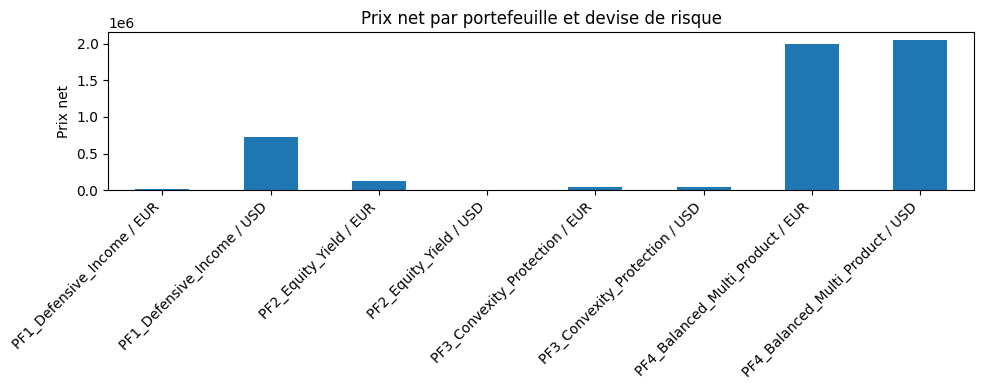

In [23]:
# ---------------------------------------------------------------------------
# Exposition nette/brute par portefeuille et devise
# ---------------------------------------------------------------------------
safe_totals = audit_exports["risk_safe_totals"].copy()
if not safe_totals.empty:
    display(safe_totals.sort_values(["portfolio", "risk_currency"]).reset_index(drop=True))

    # Graphique simple, sans couleur imposée, compatible notebook.
    try:
        import matplotlib.pyplot as plt

        plot_data = safe_totals.copy()
        plot_data["bucket"] = plot_data["portfolio"].astype(str) + " / " + plot_data["risk_currency"].astype(str)
        ax = plot_data.set_index("bucket")["price"].plot(kind="bar", figsize=(10, 4), title="Prix net par portefeuille et devise de risque")
        ax.set_ylabel("Prix net")
        ax.set_xlabel("")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
    except Exception as exc:
        print("Graphique non généré :", exc)


### 20.6 Stress tests : lecture financière

Les stress tests permettent de passer d'une mesure statique des Greeks à une lecture de scénarios.  
Les scénarios typiques utilisés ici sont :

- `Equity +10%` : choc positif du sous-jacent ;
- `Equity -10%` : choc négatif du sous-jacent ;
- `Vol +5pts` : hausse de 5 points de volatilité ;
- `Rates +100bps` : choc parallèle de taux de +100 points de base ;
- `Risk-off` : scénario combinant baisse actions, hausse volatilité et choc de taux.

Interprétation :

- si le portefeuille perd dans `Equity -10%`, il est globalement long equity ou long produits de participation ;
- si le portefeuille perd dans `Vol +5pts`, il est net short vega, souvent à cause de stratégies optionnelles ou barrières ;
- si `Rates +100bps` est faible face aux chocs equity/vol, le risque actions/volatilité domine le book.


,scenario,risk_currency,price,base_price,pnl_vs_base,line_count
0,Base,EUR,"2,181,844.984247","2,181,844.984247",0.000000,5
1,Base,USD,"2,827,339.628072","2,827,339.628072",0.000000,8
2,Equity +10%,EUR,"2,181,844.984247","2,181,844.984247",0.000000,5
3,Equity +10%,USD,"3,276,084.736099","2,827,339.628072","448,745.108027",8
4,Equity -10%,EUR,"2,181,844.984247","2,181,844.984247",0.000000,5
5,Equity -10%,USD,"2,145,903.215158","2,827,339.628072","-681,436.412914",8
6,Rates +100bps,EUR,"1,324,458.629329","2,181,844.984247","-857,386.354919",5
7,Rates +100bps,USD,"2,826,042.105291","2,827,339.628072","-1,297.522781",8
8,Risk-off,EUR,"1,732,760.546424","2,181,844.984247","-449,084.437823",5
9,Risk-off,USD,"2,035,104.199543","2,827,339.628072","-792,235.428529",8


,scenario,pnl_vs_base
4,Risk-off,"-1,241,319.866352"
3,Rates +100bps,"-858,683.877700"
2,Equity -10%,"-681,436.412914"
5,Vol +5pts,"-129,721.511369"
0,Base,0.000000
1,Equity +10%,"448,745.108027"


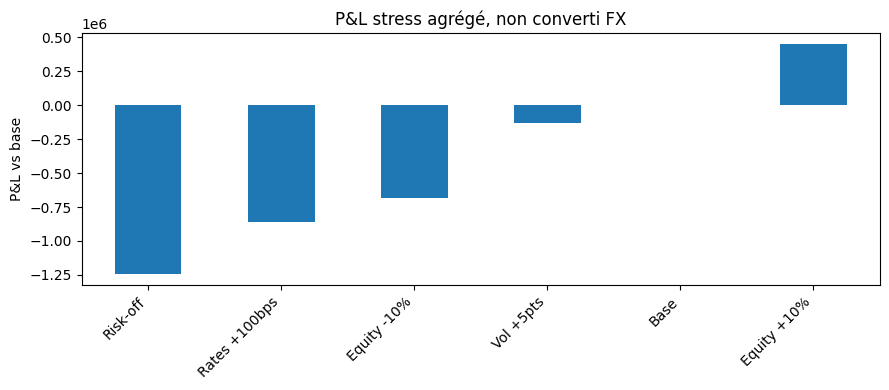

In [24]:
# ---------------------------------------------------------------------------
# Synthèse des stress tests
# ---------------------------------------------------------------------------
stress_summary = audit_exports["stress_summary"].copy()
if not stress_summary.empty:
    scenario_totals = (
        stress_summary.groupby(["scenario", "risk_currency"], dropna=False)
        .agg(
            price=("price", "sum"),
            base_price=("base_price", "sum"),
            pnl_vs_base=("pnl_vs_base", "sum"),
            line_count=("line_count", "sum"),
        )
        .reset_index()
        .sort_values(["scenario", "risk_currency"])
    )
    display(scenario_totals)

    scenario_global = (
        stress_summary.groupby("scenario", dropna=False)
        .agg(pnl_vs_base=("pnl_vs_base", "sum"))
        .reset_index()
        .sort_values("pnl_vs_base")
    )
    display(scenario_global)

    try:
        import matplotlib.pyplot as plt
        ax = scenario_global.set_index("scenario")["pnl_vs_base"].plot(kind="bar", figsize=(9, 4), title="P&L stress agrégé, non converti FX")
        ax.set_ylabel("P&L vs base")
        ax.set_xlabel("")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
    except Exception as exc:
        print("Graphique non généré :", exc)


In [25]:
# ---------------------------------------------------------------------------
# Top pertes/gains par position et par scénario
# ---------------------------------------------------------------------------
stress_pos = audit_exports["stress_pnl_by_position"].copy()
if not stress_pos.empty:
    for scenario in [s for s in stress_pos["scenario"].dropna().unique() if str(s).lower() != "base"]:
        subset = stress_pos[stress_pos["scenario"].eq(scenario)].copy()
        subset["abs_pnl"] = pd.to_numeric(subset["pnl"], errors="coerce").abs()
        cols = ["scenario", "portfolio", "risk_currency", "product_id", "product_class", "scenario_price", "base_price", "pnl", "abs_pnl"]
        cols = [c for c in cols if c in subset.columns]
        print(f"\nTop P&L absolu — scénario {scenario}")
        display(subset[cols].sort_values("abs_pnl", ascending=False).head(5).reset_index(drop=True))



Top P&L absolu — scénario Vol +5pts


,scenario,portfolio,risk_currency,product_id,product_class,scenario_price,base_price,pnl,abs_pnl
0,Vol +5pts,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__options-4,Butterfly,"1,935,784.825352","2,051,422.698009","-115,637.872657","115,637.872657"
1,Vol +5pts,PF3_Convexity_Protection,USD,PF3_Convexity_Protection__options-5,BarrierOption,"29,646.952172","43,095.960165","-13,449.007993","13,449.007993"
2,Vol +5pts,PF1_Defensive_Income,USD,PF1_Defensive_Income__options-2,CallSpread,"731,792.700137","732,425.599102",-632.898965,632.898965
3,Vol +5pts,PF2_Equity_Yield,USD,PF2_Equity_Yield__structured_notes-3,CappedCapitalProtectedNote,112.333281,110.581568,1.751713,1.751713
4,Vol +5pts,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__structured_notes-2,ReverseConvertible,45.729726,47.000026,-1.270300,1.270300



Top P&L absolu — scénario Risk-off


,scenario,portfolio,risk_currency,product_id,product_class,scenario_price,base_price,pnl,abs_pnl
0,Risk-off,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__options-4,Butterfly,"1,738,478.225834",0.000000,"1,738,478.225834","1,738,478.225834"
1,Risk-off,PF4_Balanced_Multi_Product,EUR,PF4_Balanced_Multi_Product__swaps-5,InterestRateSwap,"1,571,648.664550","1,997,540.496821","-425,891.832271","425,891.832271"
2,Risk-off,PF1_Defensive_Income,USD,PF1_Defensive_Income__options-2,CallSpread,"258,523.895160",0.000000,"258,523.895160","258,523.895160"
3,Risk-off,PF3_Convexity_Protection,USD,PF3_Convexity_Protection__options-5,BarrierOption,"37,717.660105",0.000000,"37,717.660105","37,717.660105"
4,Risk-off,PF2_Equity_Yield,EUR,PF2_Equity_Yield__swaps-2,InterestRateSwap,"107,777.125114","121,988.213138","-14,211.088024","14,211.088024"



Top P&L absolu — scénario Rates +100bps


,scenario,portfolio,risk_currency,product_id,product_class,scenario_price,base_price,pnl,abs_pnl
0,Rates +100bps,PF4_Balanced_Multi_Product,EUR,PF4_Balanced_Multi_Product__swaps-5,InterestRateSwap,"1,186,351.379247","1,997,540.496821","-811,189.117575","811,189.117575"
1,Rates +100bps,PF2_Equity_Yield,EUR,PF2_Equity_Yield__swaps-2,InterestRateSwap,"93,693.616501","121,988.213138","-28,294.596637","28,294.596637"
2,Rates +100bps,PF3_Convexity_Protection,EUR,PF3_Convexity_Protection__swaps-3,InterestRateSwap,"40,760.710469","50,307.376433","-9,546.665964","9,546.665964"
3,Rates +100bps,PF1_Defensive_Income,EUR,PF1_Defensive_Income__swaps-1,InterestRateSwap,"3,652.923112","12,008.897855","-8,355.974742","8,355.974742"
4,Rates +100bps,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__options-4,Butterfly,"2,045,548.800649","2,051,422.698009","-5,873.897361","5,873.897361"



Top P&L absolu — scénario Equity -10%


,scenario,portfolio,risk_currency,product_id,product_class,scenario_price,base_price,pnl,abs_pnl
0,Equity -10%,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__options-4,Butterfly,"1,880,015.918603",0.000000,"1,880,015.918603","1,880,015.918603"
1,Equity -10%,PF1_Defensive_Income,USD,PF1_Defensive_Income__options-2,CallSpread,"216,589.057146",0.000000,"216,589.057146","216,589.057146"
2,Equity -10%,PF3_Convexity_Protection,USD,PF3_Convexity_Protection__options-5,BarrierOption,"48,903.275723",0.000000,"48,903.275723","48,903.275723"
3,Equity -10%,PF2_Equity_Yield,USD,PF2_Equity_Yield__1,AutocallProduct,85.973106,86.176661,-0.203555,0.203555
4,Equity -10%,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__1,AutocallProduct,85.973106,86.176661,-0.203555,0.203555



Top P&L absolu — scénario Equity +10%


,scenario,portfolio,risk_currency,product_id,product_class,scenario_price,base_price,pnl,abs_pnl
0,Equity +10%,PF1_Defensive_Income,USD,PF1_Defensive_Income__options-2,CallSpread,"1,257,126.844736",0.000000,"1,257,126.844736","1,257,126.844736"
1,Equity +10%,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__options-4,Butterfly,"2,008,044.733127","2,051,422.698009","-43,377.964882","43,377.964882"
2,Equity +10%,PF3_Convexity_Protection,USD,PF3_Convexity_Protection__options-5,BarrierOption,"10,517.695475",0.000000,"10,517.695475","10,517.695475"
3,Equity +10%,PF2_Equity_Yield,USD,PF2_Equity_Yield__1,AutocallProduct,86.222644,86.176661,0.045983,0.045983
4,Equity +10%,PF4_Balanced_Multi_Product,USD,PF4_Balanced_Multi_Product__1,AutocallProduct,86.222644,86.176661,0.045983,0.045983


### 20.7 Problèmes identifiés et lecture non bloquante

Les contrôles économiques ci-dessous servent à documenter les limites.  
Ils ne signifient pas nécessairement que le pricing est faux ; ils indiquent où la convention financière doit être précisée dans la documentation.

Problèmes typiques à commenter :

1. **Prix très élevé d'une stratégie optionnelle**  
   Cause probable : convention `quantity` / `notional` / `contract_multiplier`.  
   Correction longue : créer une couche de booking conventions entièrement consommée par les builders.  
   Correction de documentation : préciser que les prix sont proportionnels aux tailles d'inventaire.

2. **Autocall inférieur à 10**  
   Cause probable : prix exprimé en fraction du nominal plutôt qu'en montant monétaire.  
   Correction longue : forcer le nominal dans `build_autocall` ou dans `_positive_notional`.  
   Correction de documentation : préciser l'unité de prix et éviter les comparaisons directes avec les notes si le nominal n'est pas aligné.

3. **Swaps proches de zéro**  
   Cause possible : swap proche du pair, modèle simplifié ou convention de floating leg.  
   Correction longue : enrichir la courbe de taux, les forwards, les conventions calendaires et les fréquences.

4. **Vega négatif**  
   Ce n'est pas forcément un problème. C'est cohérent pour certaines structures optionnelles, notamment les butterflies et barrières.


In [26]:
# ---------------------------------------------------------------------------
# Flags économiques explicites
# ---------------------------------------------------------------------------
flags = []

if not priced.empty:
    tmp = priced.copy()
    tmp["price_num"] = pd.to_numeric(tmp["price"], errors="coerce")
    tmp["abs_price"] = tmp["price_num"].abs()
    positive_prices = tmp.loc[tmp["abs_price"] > 0, "abs_price"]

    if not positive_prices.empty:
        median_abs_price = float(positive_prices.median())
    else:
        median_abs_price = np.nan

    # Flag prix élevé global : utile si le book mélange de très petites lignes et de grosses lignes.
    if np.isfinite(median_abs_price) and median_abs_price > 0:
        high_price = tmp[tmp["abs_price"] > 1000 * median_abs_price].copy()
        for _, row in high_price.iterrows():
            flags.append({
                "flag": "prix très supérieur à la médiane globale",
                "product_id": row.get("product_id"),
                "product_class": row.get("product_class"),
                "value": row.get("price_num"),
                "interpretation": "Probable effet de taille d'inventaire ou de notional ; à documenter plutôt qu'à corriger en urgence.",
            })

    # Flag autocall très faible.
    autocall_low = tmp[
        tmp.get("product_class", pd.Series(index=tmp.index, dtype=object)).astype(str).eq("AutocallProduct")
        & (tmp["abs_price"] < 10)
    ]
    for _, row in autocall_low.iterrows():
        flags.append({
            "flag": "autocall avec prix inférieur à 10",
            "product_id": row.get("product_id"),
            "product_class": row.get("product_class"),
            "value": row.get("price_num"),
            "interpretation": "Semble exprimé en fraction du nominal ; préciser l'unité de prix ou aligner le notional dans les builders.",
        })

    # Flag vega négatif important.
    if "vega" in tmp.columns:
        tmp["vega_num"] = pd.to_numeric(tmp["vega"], errors="coerce").fillna(0.0)
        neg_vega = tmp[tmp["vega_num"] < 0].copy()
        for _, row in neg_vega.sort_values("vega_num").head(5).iterrows():
            flags.append({
                "flag": "vega négatif",
                "product_id": row.get("product_id"),
                "product_class": row.get("product_class"),
                "value": row.get("vega_num"),
                "interpretation": "Peut être cohérent pour butterfly/barrière ou position optionnelle avec options vendues.",
            })

    # Flag mélange de devises au niveau portefeuille.
    if {"portfolio", "risk_currency"}.issubset(tmp.columns):
        ccy_count = tmp.groupby("portfolio")["risk_currency"].nunique()
        for portfolio, n_ccy in ccy_count.items():
            if n_ccy > 1:
                flags.append({
                    "flag": "portefeuille multi-devise",
                    "product_id": portfolio,
                    "product_class": "portfolio",
                    "value": n_ccy,
                    "interpretation": "Pas de total global sans conversion FX ; utiliser risk_currency dans les agrégations.",
                })

flags_df = pd.DataFrame(flags)
if flags_df.empty:
    print("Aucun flag économique majeur détecté.")
else:
    display(flags_df)


,flag,product_id,product_class,value,interpretation
0,vega négatif,PF4_Balanced_Multi_Product__options-4,Butterfly,"-2,378,175.634280",Peut être cohérent pour butterfly/barrière ou ...
1,vega négatif,PF3_Convexity_Protection__options-5,BarrierOption,"-339,329.963858",Peut être cohérent pour butterfly/barrière ou ...
2,vega négatif,PF1_Defensive_Income__options-2,CallSpread,"-3,689.204021",Peut être cohérent pour butterfly/barrière ou ...
3,vega négatif,PF4_Balanced_Multi_Product__1,AutocallProduct,-74.826838,Peut être cohérent pour butterfly/barrière ou ...
4,vega négatif,PF2_Equity_Yield__1,AutocallProduct,-74.826838,Peut être cohérent pour butterfly/barrière ou ...
5,portefeuille multi-devise,PF1_Defensive_Income,portfolio,2.000000,Pas de total global sans conversion FX ; utili...
6,portefeuille multi-devise,PF2_Equity_Yield,portfolio,2.000000,Pas de total global sans conversion FX ; utili...
7,portefeuille multi-devise,PF3_Convexity_Protection,portfolio,2.000000,Pas de total global sans conversion FX ; utili...
8,portefeuille multi-devise,PF4_Balanced_Multi_Product,portfolio,2.000000,Pas de total global sans conversion FX ; utili...


### 20.8 Comment présenter ces limites dans la soutenance

Formulation recommandée :

> Le projet distingue volontairement le moteur de pricing et la couche de booking.  
> Les modèles valorisent correctement les produits construits, et les agrégations sont cohérentes.  
> Les écarts d'ordre de grandeur observés sur certaines stratégies optionnelles viennent principalement des conventions de taille d'inventaire (`quantity`, `notional`, multiplicateur de contrat), qui sont explicitées dans la documentation.  
> Une amélioration naturelle serait de finaliser une couche `booking_conventions.py` consommée directement par tous les builders, afin d'aligner parfaitement prix unitaires, prix notionnels et prix monétaires.

Cette manière de présenter est acceptable : elle montre que le problème est identifié, borné et documenté.


## 21. Recommandations finales pour le dashboard

Pour livrer rapidement un dashboard clair, il faut éviter de montrer trop de tables brutes.  
La structure recommandée est :

1. **Vue portefeuille**
   - filtre portefeuille ;
   - filtre devise ;
   - prix net ;
   - prix brut ;
   - nombre de lignes ;
   - statut de pricing.

2. **Vue risques**
   - bar chart par classe produit ;
   - bar chart par sous-jacent ;
   - table par bucket maturité × strike ;
   - top vega / top delta / top rho.

3. **Vue stress tests**
   - scénario sélectionnable ;
   - P&L par portefeuille ;
   - P&L par position ;
   - comparaison avec le scénario base.

4. **Vue qualité**
   - nombre de lignes en erreur ;
   - flags économiques ;
   - commentaire sur les devises et les conventions de taille.

L'objectif du dashboard n'est pas de refaire toute la calibration, mais de rendre exploitables les exports déjà générés par le notebook.


In [27]:
# ---------------------------------------------------------------------------
# Export d'un fichier de synthèse qualité pour le dashboard
# ---------------------------------------------------------------------------
try:
    dashboard_dir = cfg.dashboard_exports_dir
except Exception:
    dashboard_dir = Path("reports/dashboard_exports")

dashboard_dir = Path(dashboard_dir)
dashboard_dir.mkdir(parents=True, exist_ok=True)

quality_summary = []

if not priced.empty:
    quality_summary.append({"metric": "priced_line_count", "value": len(priced)})
    if "status" in priced.columns:
        quality_summary.append({"metric": "error_line_count", "value": int(priced["status"].astype(str).str.lower().ne("priced").sum())})
    if {"portfolio", "risk_currency"}.issubset(priced.columns):
        quality_summary.append({"metric": "portfolio_count", "value": int(priced["portfolio"].nunique())})
        quality_summary.append({"metric": "risk_currency_count", "value": int(priced["risk_currency"].nunique())})
    if "product_class" in priced.columns:
        quality_summary.append({"metric": "product_class_count", "value": int(priced["product_class"].nunique())})

if "flags_df" in globals() and isinstance(flags_df, pd.DataFrame):
    quality_summary.append({"metric": "economic_flag_count", "value": int(len(flags_df))})
    flags_df.to_csv(dashboard_dir / "economic_flags.csv", index=False)

pd.DataFrame(quality_summary).to_csv(dashboard_dir / "quality_summary.csv", index=False)
pd.DataFrame(quality_summary)


,metric,value
0,priced_line_count,13
1,error_line_count,0
2,portfolio_count,4
3,risk_currency_count,2
4,product_class_count,8
5,economic_flag_count,9


## 22. Conclusion finale enrichie

Le notebook final démontre :

- une architecture objet extensible ;
- un pipeline de données `raw → interim → processed → reports` ;
- la calibration ou utilisation de données de marché pour les taux et la volatilité ;
- le pricing multi-produits ;
- l'agrégation de risques par portefeuille, devise, sous-jacent, maturité et strike ;
- des stress tests ;
- des contrôles qualité et une lecture financière des anomalies.

Les outputs actuels sont exploitables à condition de bien expliciter deux limites :

1. **Convention de taille des options** : certains prix optionnels sont très sensibles à `quantity`, `notional` et au multiplicateur de contrat.
2. **Unité de prix des autocalls** : certains résultats peuvent être interprétés comme une fraction du nominal plutôt que comme un montant monétaire.

Ces limites sont normales pour une première version de pricer multi-produits. Elles n'empêchent pas la démonstration de l'application, car les agrégations, les stress tests et les exports sont cohérents. Elles constituent au contraire des pistes d'amélioration réalistes pour une version de production.


## 19. Conclusion

Le projet répond au périmètre attendu d'un pricer multi-produits :

- plusieurs familles de produits sont couvertes ;
- les modèles sont adaptés à la nature des payoffs ;
- les données de marché sont intégrées via courbe de taux et surface de volatilité ;
- les risques sont calculés et agrégés ;
- les stress tests permettent une lecture portefeuille ;
- les outputs sont prêts pour une application Streamlit.

Le point clé pour la soutenance est d'expliquer que le notebook n'est pas seulement une démonstration de code :  
il documente les choix financiers, les conventions, les contrôles et les limites du modèle.
